In [1]:
import SRC
import os
import sys
from SRC.helpFolder import *

metadata = SRC.load_model_metadata()

In [2]:
metadata['weatherInformation']['weather_end_date'], metadata['PMSInformation']['end_date_range']

('2025-06-07', '2025-08-30')

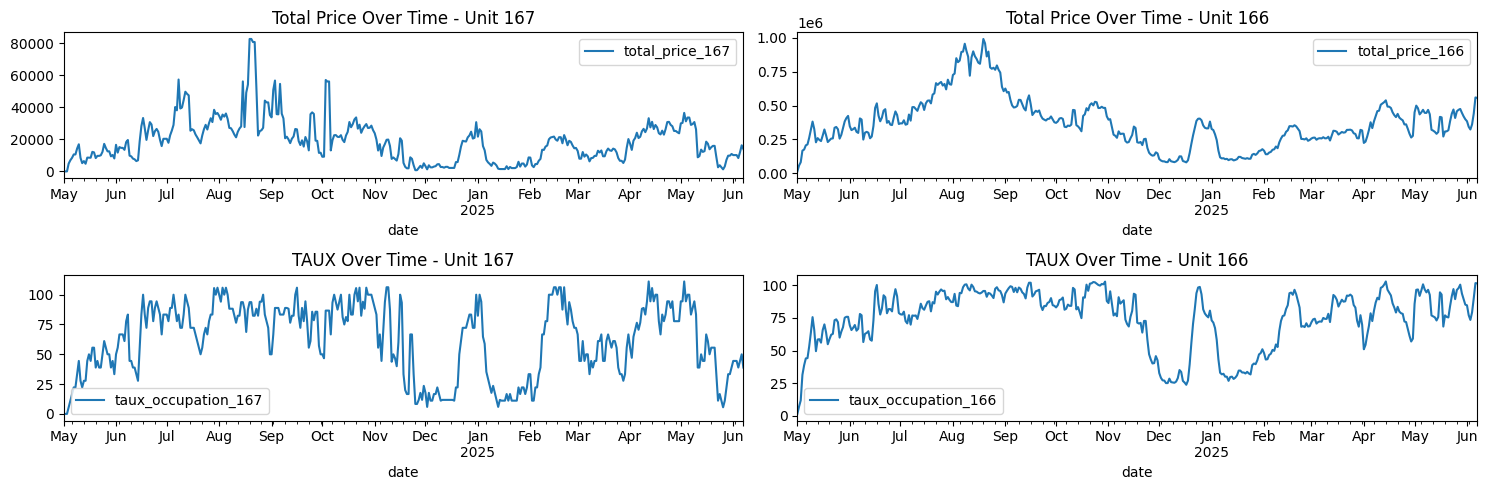

In [3]:
df_167, df_166 = prepare_and_plot_data(
    csv_path = metadata['PMSInformation']['final_csv_path'],
    start_date = metadata['PMSInformation']['start_date_range'],
    end_date = metadata['weatherInformation']['weather_end_date']
)

In [4]:
df_weather = make_weather_data_dataframe(weather_data_path = f"../{metadata['weatherInformation']['archive_json_path']}")

In [5]:
df_166_weather = concatenate_on_index(df_166, df_weather)
df_167_weather = concatenate_on_index(df_167, df_weather)

In [6]:
weather_data_dict = load_weather_data_from_json(
    json_file_path=f"../{metaData['weatherInformation']['archive_json_path']}"
)

Successfully loaded weather data for 403 dates from ../../Data/WeatherData/weather_data.json


### Train the LR modele using the **weather data**

--- Starting Linear Regression Pipeline for Unit 166 ---
Target type: taux (predicting occupancy rate)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_166
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: taux_occupation_166
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set size: 322 samples
Testing set size: 81 samples

Model Evaluation Metrics:
Train RMSE: 12.78
Test RMSE: 10.04
Train MAE: 10.68
Test MAE: 8.12
Train R²: 0.6930
Test R²: 0.3171

Feature Importance (Coefficients):
              Feature  Coefficient
2                year     8.38793

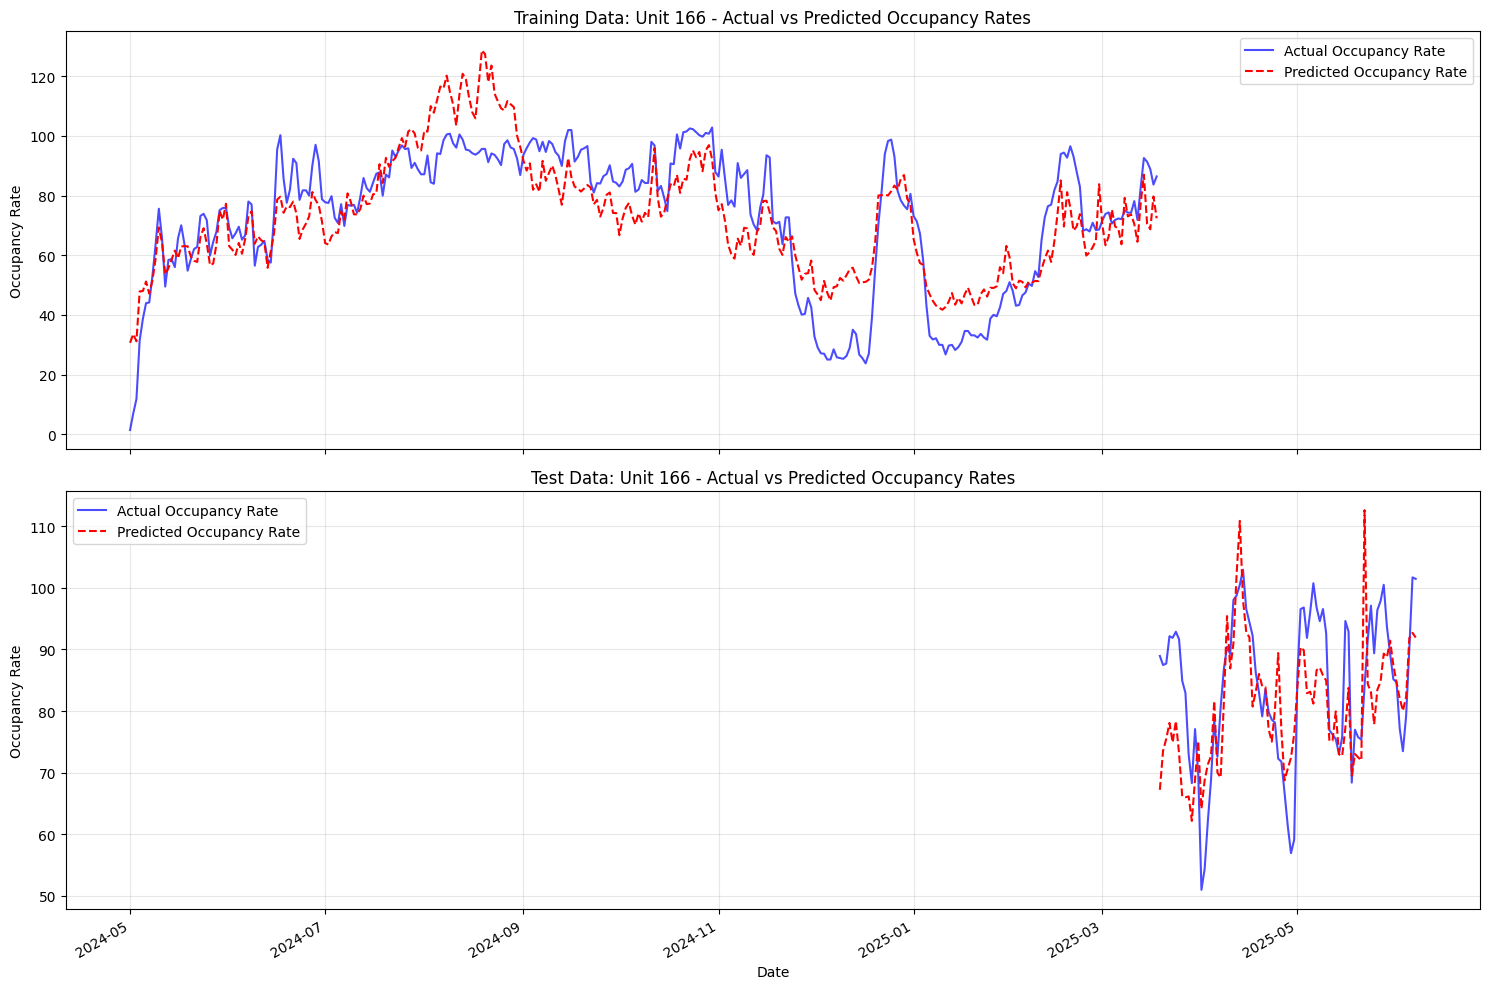

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: taux_occupation_166


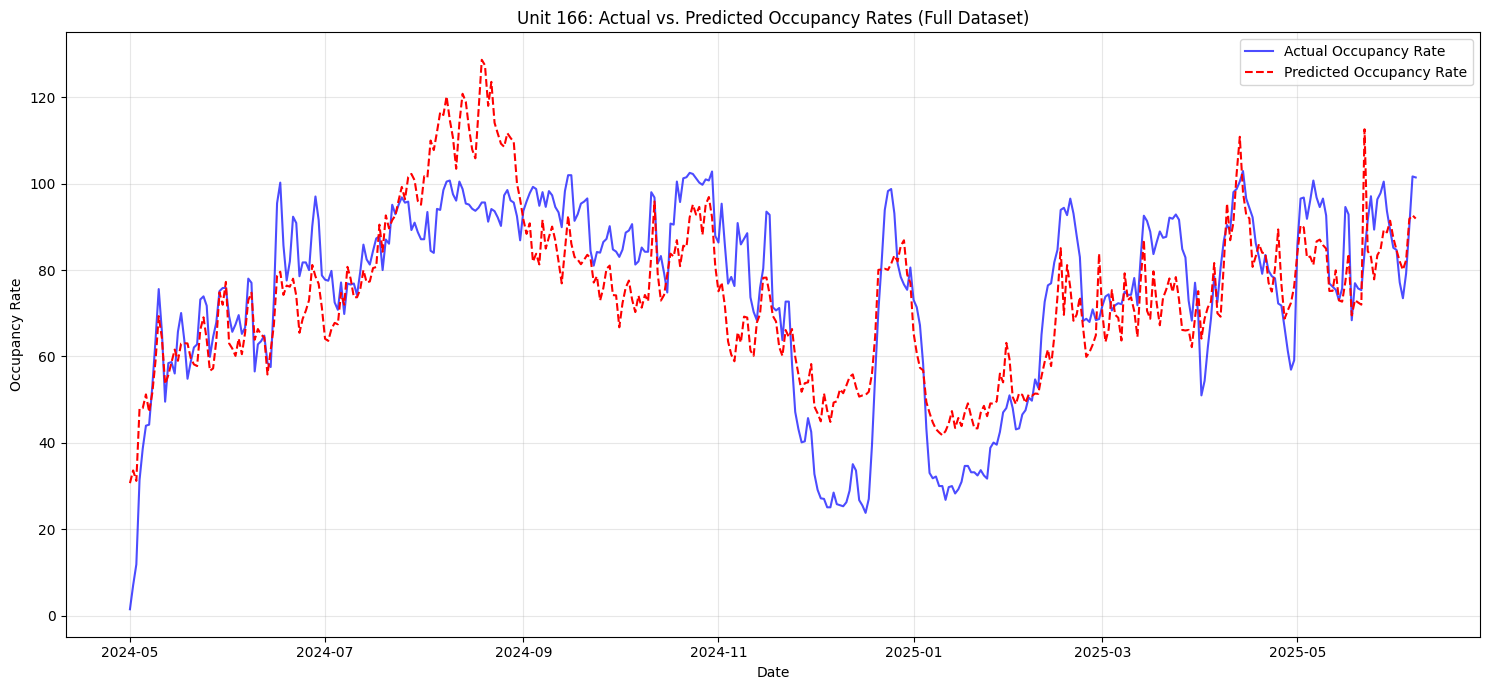


Pipeline finished for Unit 166.
--- End Linear Regression Pipeline ---
--- Starting Linear Regression Pipeline for Unit 167 ---
Target type: taux (predicting occupancy rate)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_167
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: taux_occupation_167
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set size: 322 samples
Testing set size: 81 samples

Model Evaluation Metrics:
Train RMSE: 20.76
Test RMSE: 16.23
Train MAE: 17.34
Test MAE: 12.69
Train R²: 0.5432
Test R²: 0.6241

Feature Importance (Coefficien

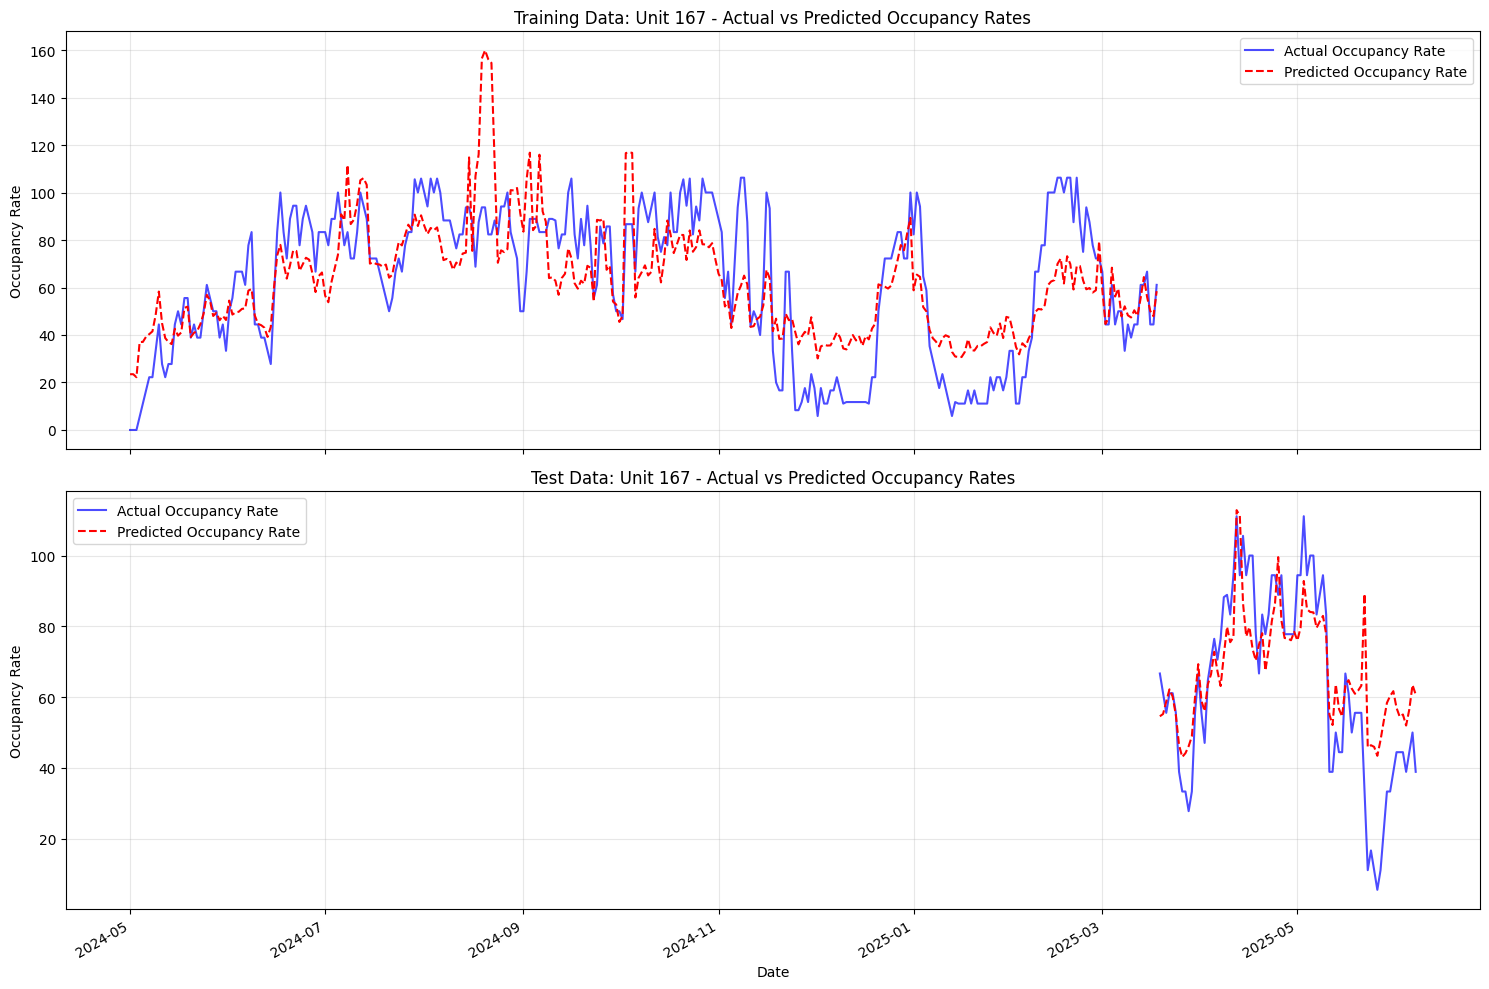

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: taux_occupation_167


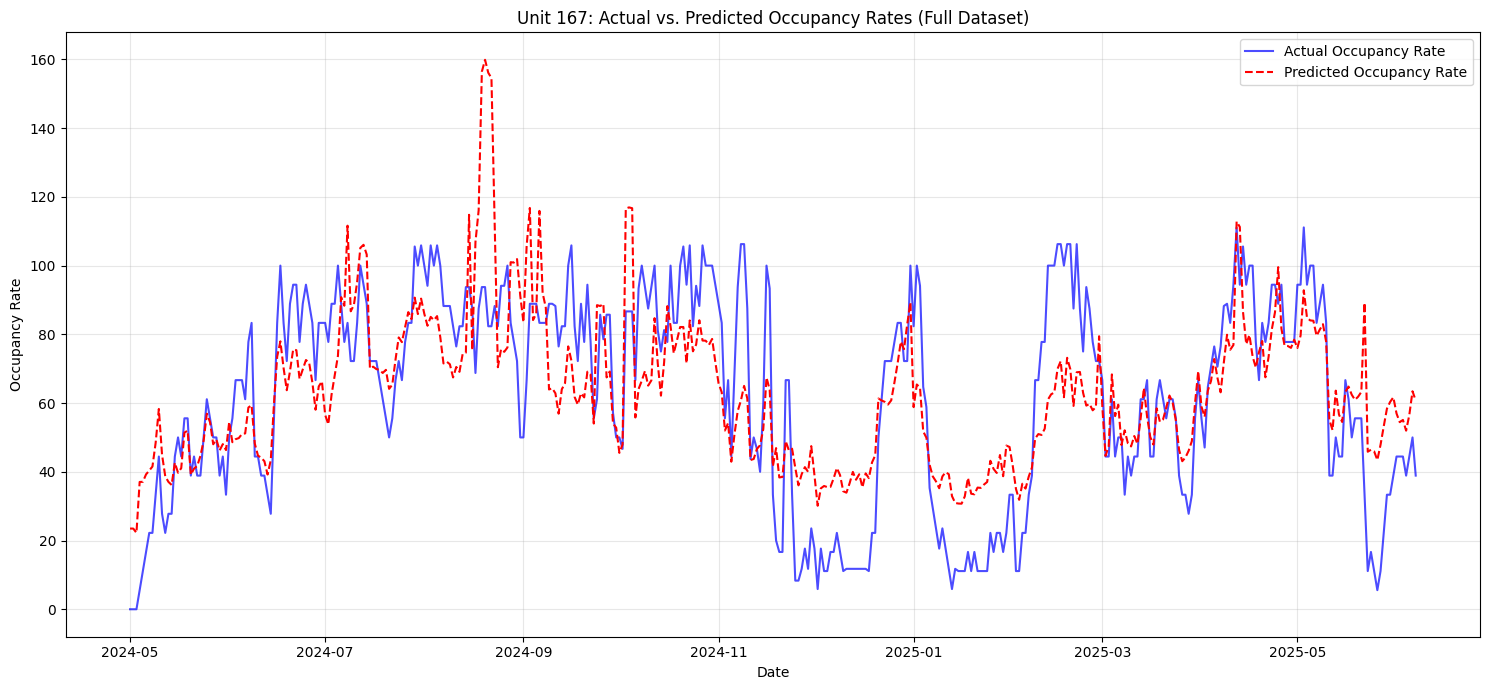


Pipeline finished for Unit 167.
--- End Linear Regression Pipeline ---


In [6]:
results_rl_taux_166 = run_linear_regression_pipeline(df_166_weather, unit_id='166', target_type='taux')
results_rl_taux_167 = run_linear_regression_pipeline(df_167_weather, unit_id='167', target_type='taux')

In [7]:
metaData['LSTMModelsV3']

{'version': 'v3',
 'taux_167': {'folder_path': '../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels',
  'model_name': 'lstm_v3_model_167_taux'},
 'taux_166': {'folder_path': '../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels',
  'model_name': 'lstm_v3_model_166_taux'},
 'price_167': {'folder_path': '../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels',
  'model_name': 'lstm_v3_model_167_price'},
 'price_166': {'folder_path': '../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels',
  'model_name': 'lstm_v3_model_166_price'}}

In [9]:
save_lr_model(
    results_rl_taux_166,
    metadata['LinearRegressionModelsV3']['taux_166']['folder_path'], 
    metadata['LinearRegressionModelsV3']['taux_166']['model_name']
)

save_lr_model(
    results_rl_taux_167, 
    metadata['LinearRegressionModelsV3']['taux_167']['folder_path'],
    metadata['LinearRegressionModelsV3']['taux_167']['model_name']
)

Created directory: ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LinearRegression
Model successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LinearRegression\linear_regression_v3_model_166.pkl
Model successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LinearRegression\linear_regression_v3_model_167.pkl


'../TrainedModels/UnitsBasedModelsV3/PredictTaux/LinearRegression\\linear_regression_v3_model_167.pkl'

--- Starting Linear Regression Pipeline for Unit 166 ---
Target type: price (predicting price)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_166
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: total_price_166
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set size: 322 samples
Testing set size: 81 samples

Model Evaluation Metrics:
Train RMSE: 92994.81
Test RMSE: 91979.60
Train MAE: 69371.81
Test MAE: 76180.75
Train R²: 0.7976
Test R²: -0.2264

Feature Importance (Coefficients):
                Feature   Coefficient
2                  year  517

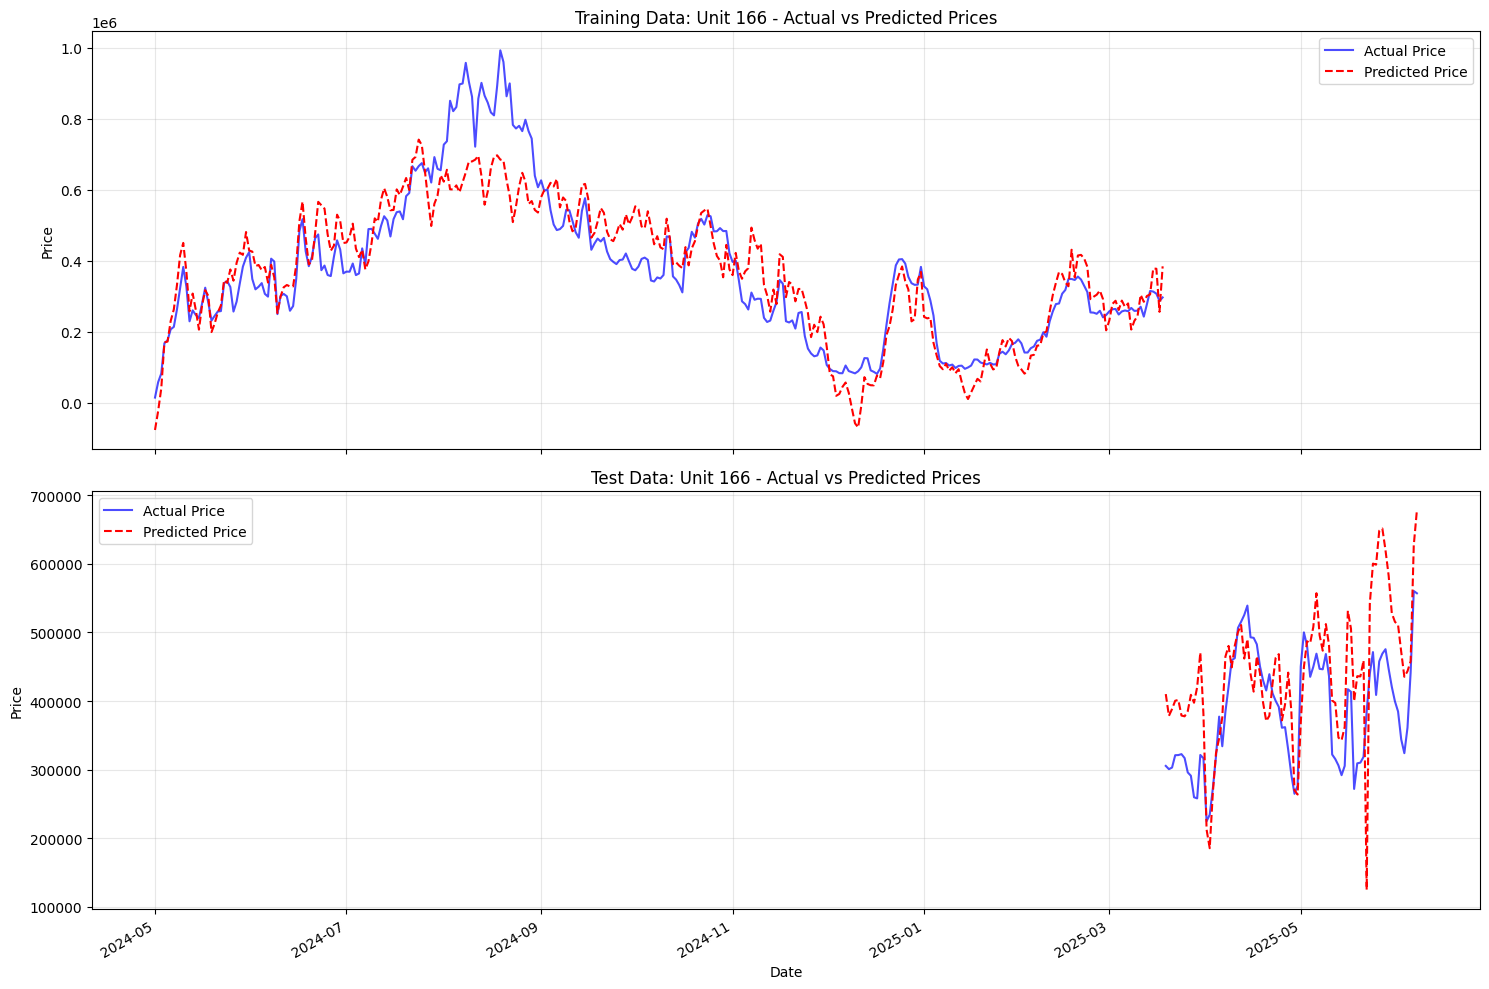

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: total_price_166


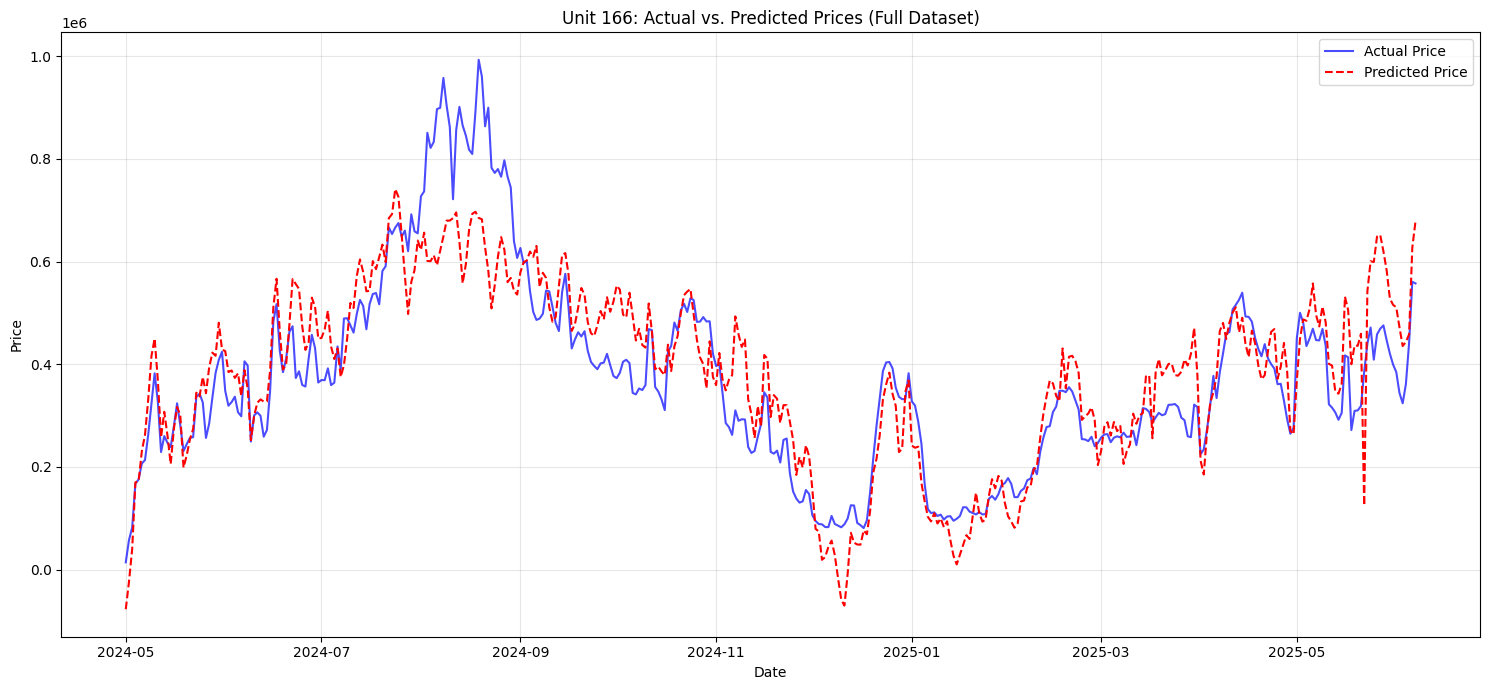


Pipeline finished for Unit 166.
--- End Linear Regression Pipeline ---
--- Starting Linear Regression Pipeline for Unit 167 ---
Target type: price (predicting price)

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_167
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: total_price_167
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set size: 322 samples
Testing set size: 81 samples

Model Evaluation Metrics:
Train RMSE: 8943.05
Test RMSE: 5043.24
Train MAE: 5869.05
Test MAE: 3856.67
Train R²: 0.6247
Test R²: 0.6938

Feature Importance (Coefficients):

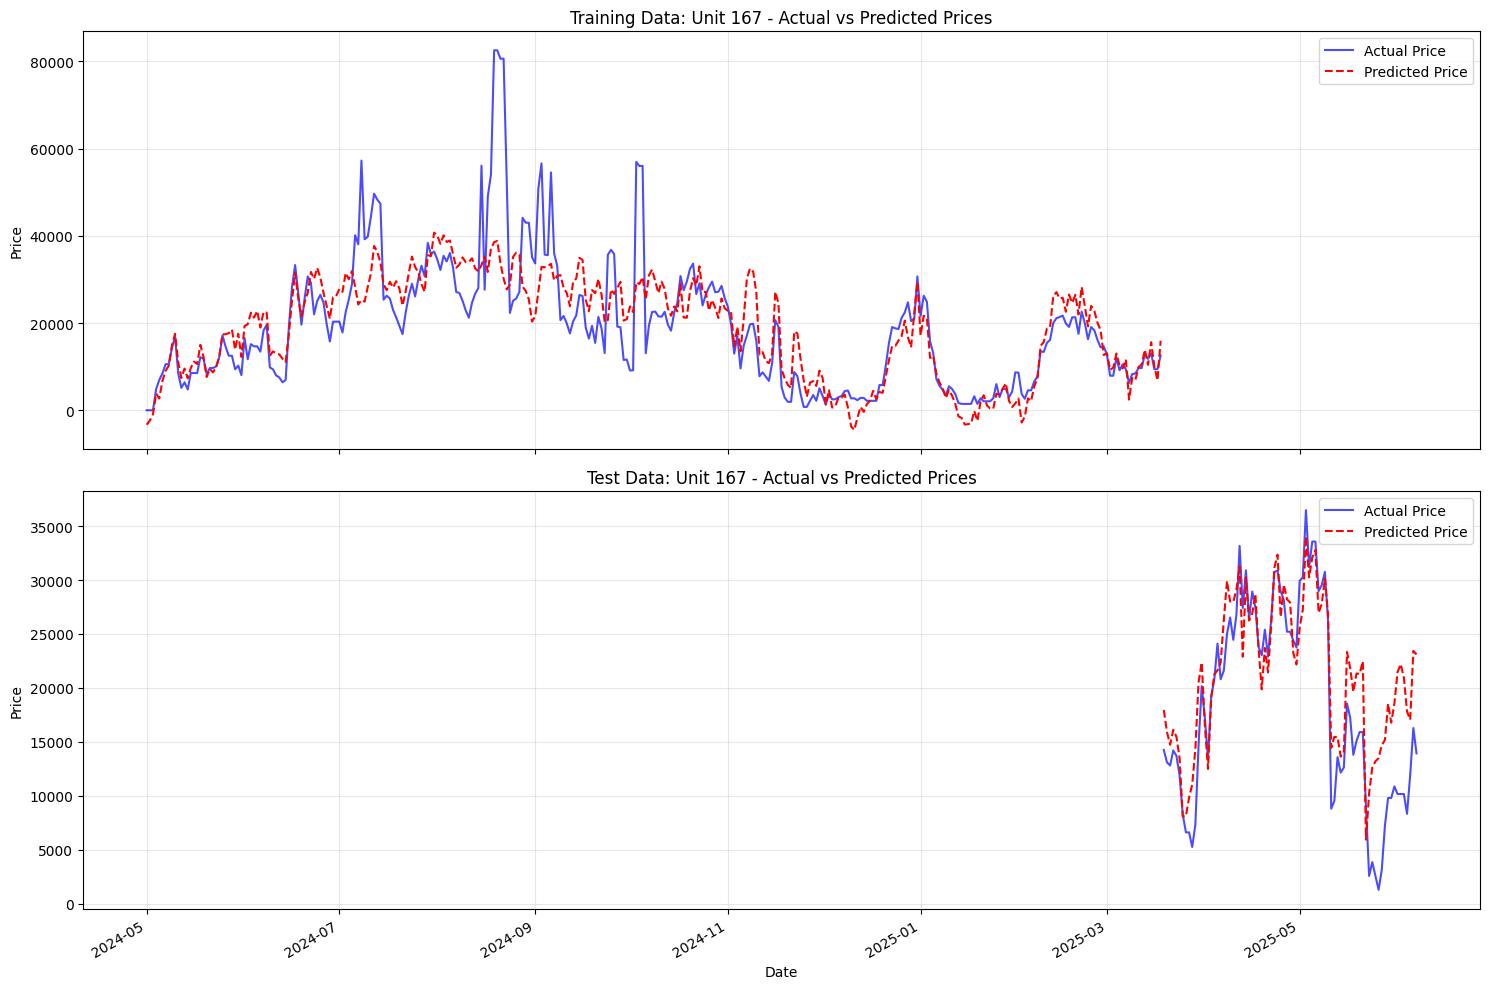

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: total_price_167


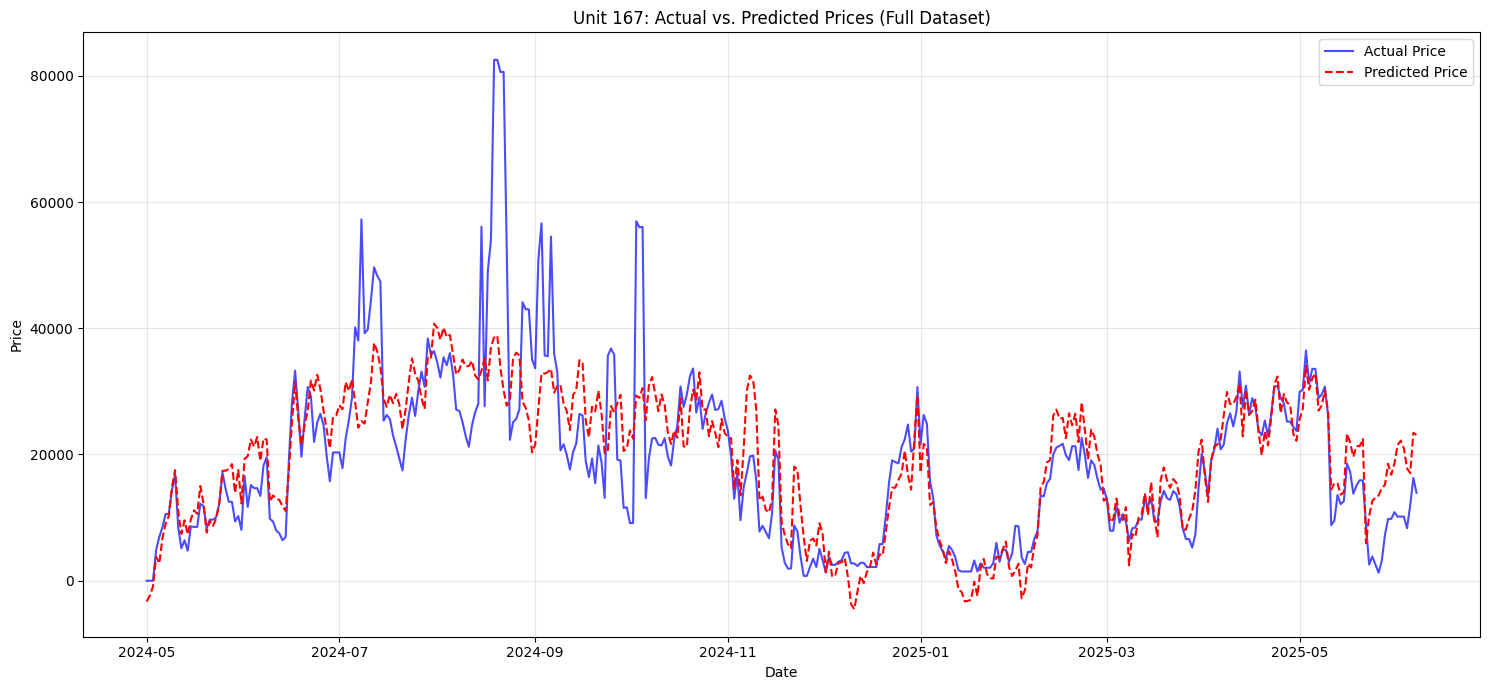


Pipeline finished for Unit 167.
--- End Linear Regression Pipeline ---


In [10]:
results_rl_price_166 = run_linear_regression_pipeline(df_166_weather, unit_id='166', target_type='price')
results_rl_price_167 = run_linear_regression_pipeline(df_167_weather, unit_id='167', target_type='price')

In [11]:
save_lr_model(
    results_rl_price_166,
    metadata['LinearRegressionModelsV3']['price_166']['folder_path'], 
    metadata['LinearRegressionModelsV3']['price_166']['model_name']
)

save_lr_model(
    results_rl_price_167, 
    metadata['LinearRegressionModelsV3']['price_167']['folder_path'],
    metadata['LinearRegressionModelsV3']['price_167']['model_name']
)

Created directory: ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LinearRegression
Model successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LinearRegression\linear_model_v3_166.pkl
Model successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LinearRegression\linear_model_v3_167.pkl


'../TrainedModels/UnitsBasedModelsV3/PredictPrice/LinearRegression\\linear_model_v3_167.pkl'

In [17]:
results = find_max_output_for_date_range_linear_model(
    start_date_str= '2025-04-20',
    end_date_str= '2025-04-30',
    unit_id='166',
    min_value= 30.0,
    max_value= 100.0,
    step=1,
    target_type='price',
    modelsName='LinearRegressionModelsV3',
    weather_data_dict= weather_data,
)

Loading model for target='price', unit='166'...
Model name: linear_model_v3_166
Model successfully loaded from ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LinearRegression\linear_model_v3_166.pkl
Model loaded successfully.

Searching for optimal taux_occupation for unit 166 on 2025-04-20
Range: 30.00-100.00, step: 1
Target: maximize predicted price


Testing taux_occupation values:  14%|█▍        | 10/71 [00:00<00:00, 95.64it/s]

Weather data successfully retrieved from pre-loaded data for 2025-04-20

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          6      4  2025        110          16                 30.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           22.226           12.776            16.818            0.0   

   windspeed_max  temperature_range  
0         13.259               9.45  
Weather data successfully retrieved from pre-loaded data for 2025-04-20

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          6      4  2025        110          16                 31.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           22.226           12.776            16.818            0.0   

   windspeed_max  temperature_range  
0         13.259  

Testing taux_occupation values:  32%|███▏      | 23/71 [00:00<00:00, 111.78it/s]

Weather data successfully retrieved from pre-loaded data for 2025-04-20

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          6      4  2025        110          16                 50.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           22.226           12.776            16.818            0.0   

   windspeed_max  temperature_range  
0         13.259               9.45  
Weather data successfully retrieved from pre-loaded data for 2025-04-20

Predicting total_price_166 for Unit 166 on 2025-04-20 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          6      4  2025        110          16                 51.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           22.226           12.776            16.818            0.0   

   windspeed_max  temperature_range  
0         13.259  

...

Weather data successfully retrieved from pre-loaded data for 2025-04-30

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          2      4  2025        120          18                 53.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           20.076           13.726            16.166            1.0   

   windspeed_max  temperature_range  
0         15.329               6.35  
Weather data successfully retrieved from pre-loaded data for 2025-04-30

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          2      4  2025        120          18                 54.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           20.076           13.726            16.166            1.0   

   windspeed_max  temperature_range  
0         15.329  

Testing taux_occupation values:  59%|█████▉    | 42/71 [00:00<00:00, 128.28it/s]

Weather data successfully retrieved from pre-loaded data for 2025-04-30

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          2      4  2025        120          18                 58.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           20.076           13.726            16.166            1.0   

   windspeed_max  temperature_range  
0         15.329               6.35  
Weather data successfully retrieved from pre-loaded data for 2025-04-30

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          2      4  2025        120          18                 59.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           20.076           13.726            16.166            1.0   

   windspeed_max  temperature_range  
0         15.329  

Testing taux_occupation values: 100%|██████████| 71/71 [00:00<00:00, 116.82it/s]

Weather data successfully retrieved from pre-loaded data for 2025-04-30

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          2      4  2025        120          18                 80.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           20.076           13.726            16.166            1.0   

   windspeed_max  temperature_range  
0         15.329               6.35  
Weather data successfully retrieved from pre-loaded data for 2025-04-30

Predicting total_price_166 for Unit 166 on 2025-04-30 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          2      4  2025        120          18                 81.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           20.076           13.726            16.166            1.0   

   windspeed_max  temperature_range  
0         15.329  

In [18]:
results

{'2025-04-20': {'best_input': 100.0, 'max_output': 476143.0766903609},
 '2025-04-21': {'best_input': 100.0, 'max_output': 461916.04878497124},
 '2025-04-22': {'best_input': 100.0, 'max_output': 526898.2818282545},
 '2025-04-23': {'best_input': 100.0, 'max_output': 571150.4380276799},
 '2025-04-24': {'best_input': 100.0, 'max_output': 579074.1165114492},
 '2025-04-25': {'best_input': 100.0, 'max_output': 511910.77400036156},
 '2025-04-26': {'best_input': 100.0, 'max_output': 537754.9800699204},
 '2025-04-27': {'best_input': 100.0, 'max_output': 609838.0142768174},
 '2025-04-28': {'best_input': 100.0, 'max_output': 580385.5524371117},
 '2025-04-29': {'best_input': 100.0, 'max_output': 487462.9633767903},
 '2025-04-30': {'best_input': 100.0, 'max_output': 470122.7953328639}}

### Train the XGBoost model on the **weather data**

--- Starting XGBoost Pipeline for Unit 166 ---
Target type: taux

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_166
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: taux_occupation_166
Hyperparameters: n_estimators=3000, lr=0.01, max_depth=20
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set size: 322 samples
Testing set size: 81 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 0.00
Test RMSE: 11.25
Train MAE: 0.00
Test MAE: 9.72
Train R²: 1.0000
Test R²: 0.1428

Feature Importance:
              Feature  Importance
5     tota

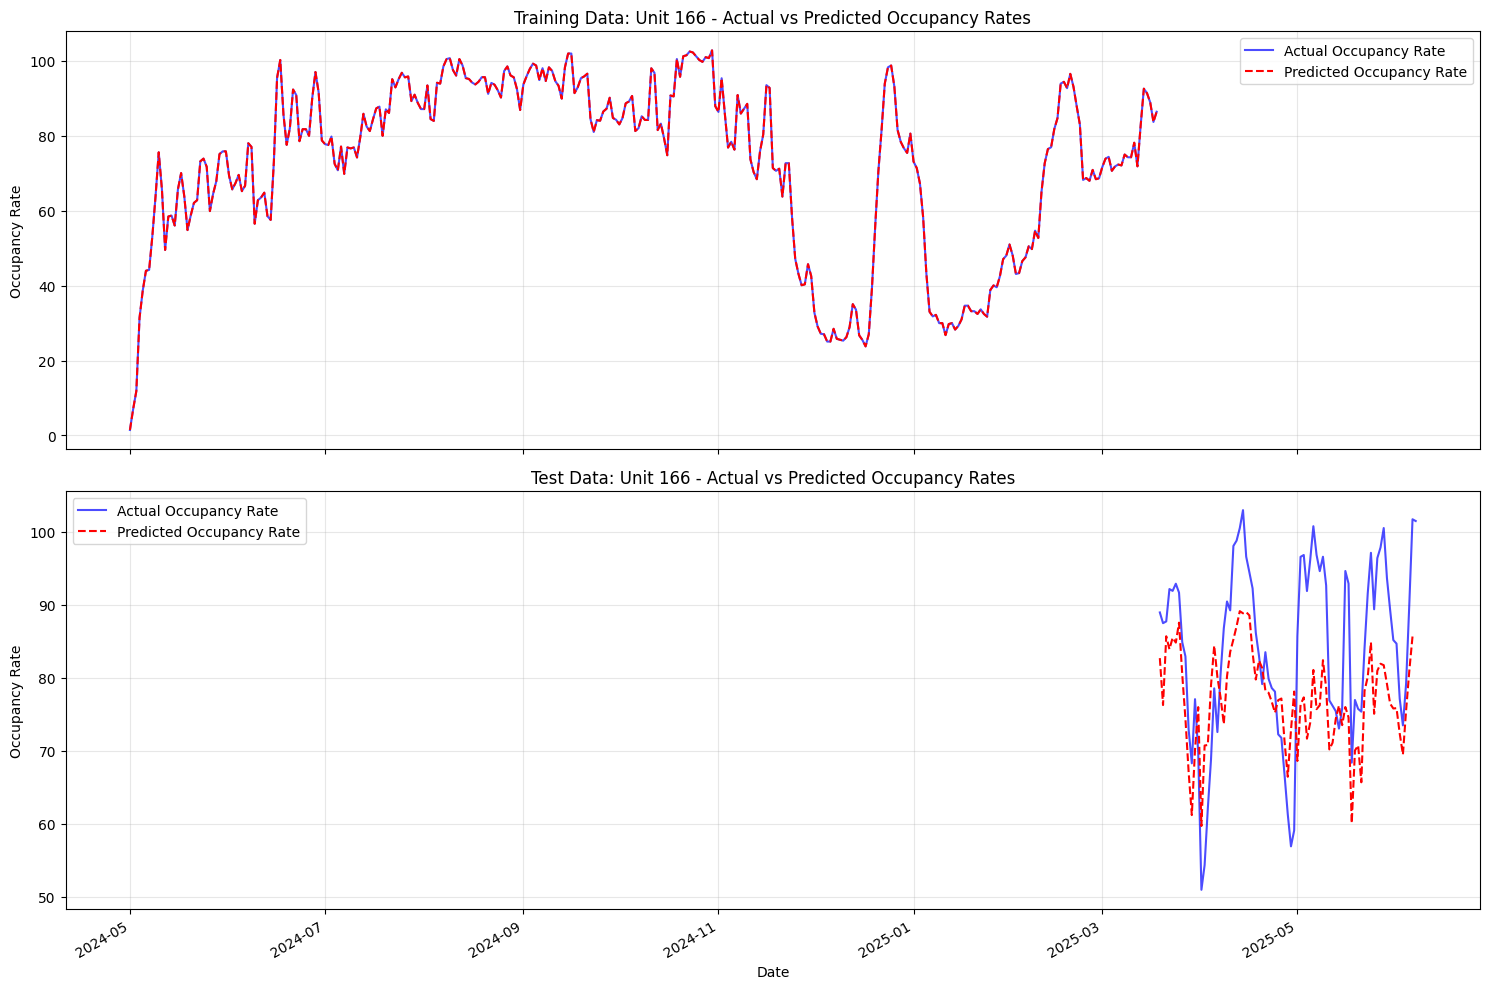

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: taux_occupation_166


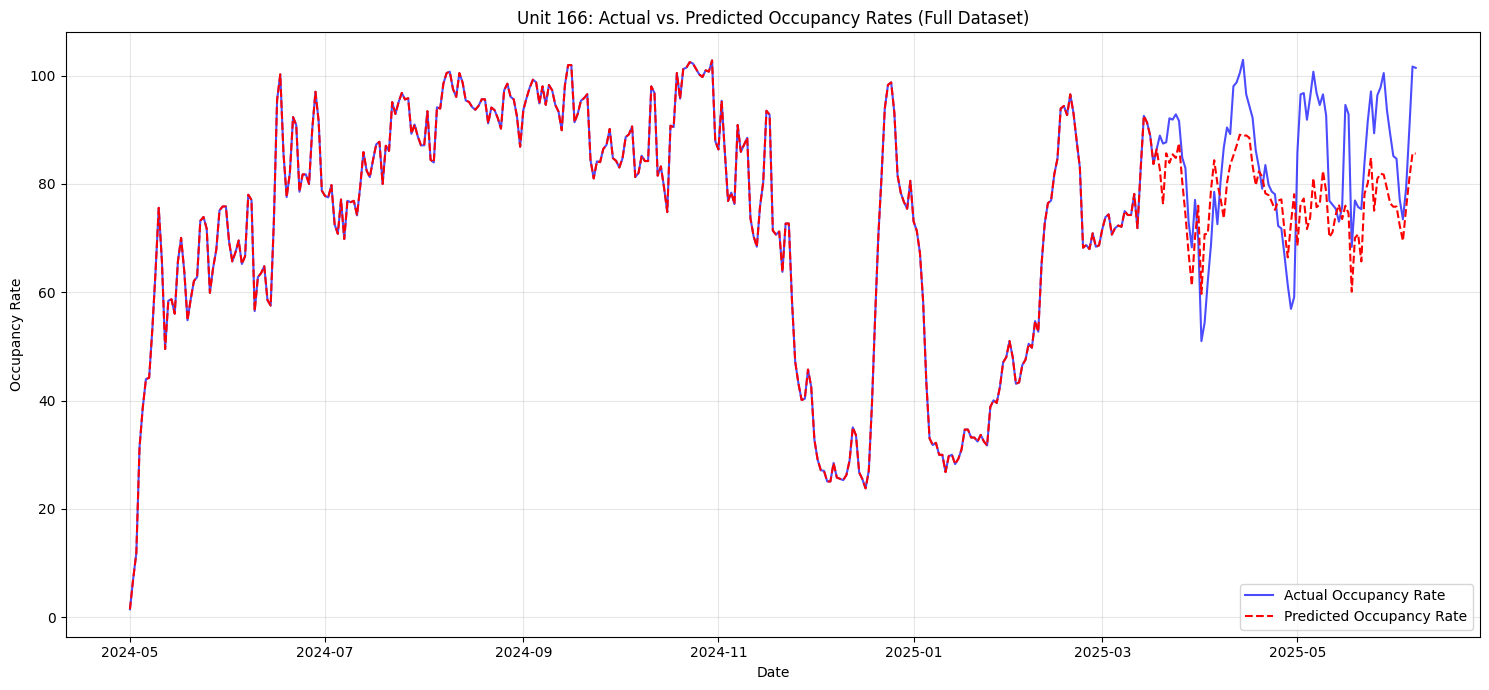


Pipeline finished for Unit 166 (target: taux).
--- End XGBoost Pipeline ---
--- Starting XGBoost Pipeline for Unit 167 ---
Target type: taux

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_167
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: taux_occupation_167
Hyperparameters: n_estimators=3000, lr=0.01, max_depth=20
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set size: 322 samples
Testing set size: 81 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 0.00
Test RMSE: 12.63
Train MAE: 0.00
Test MAE: 10.26
Train R²: 1.0000
Tes

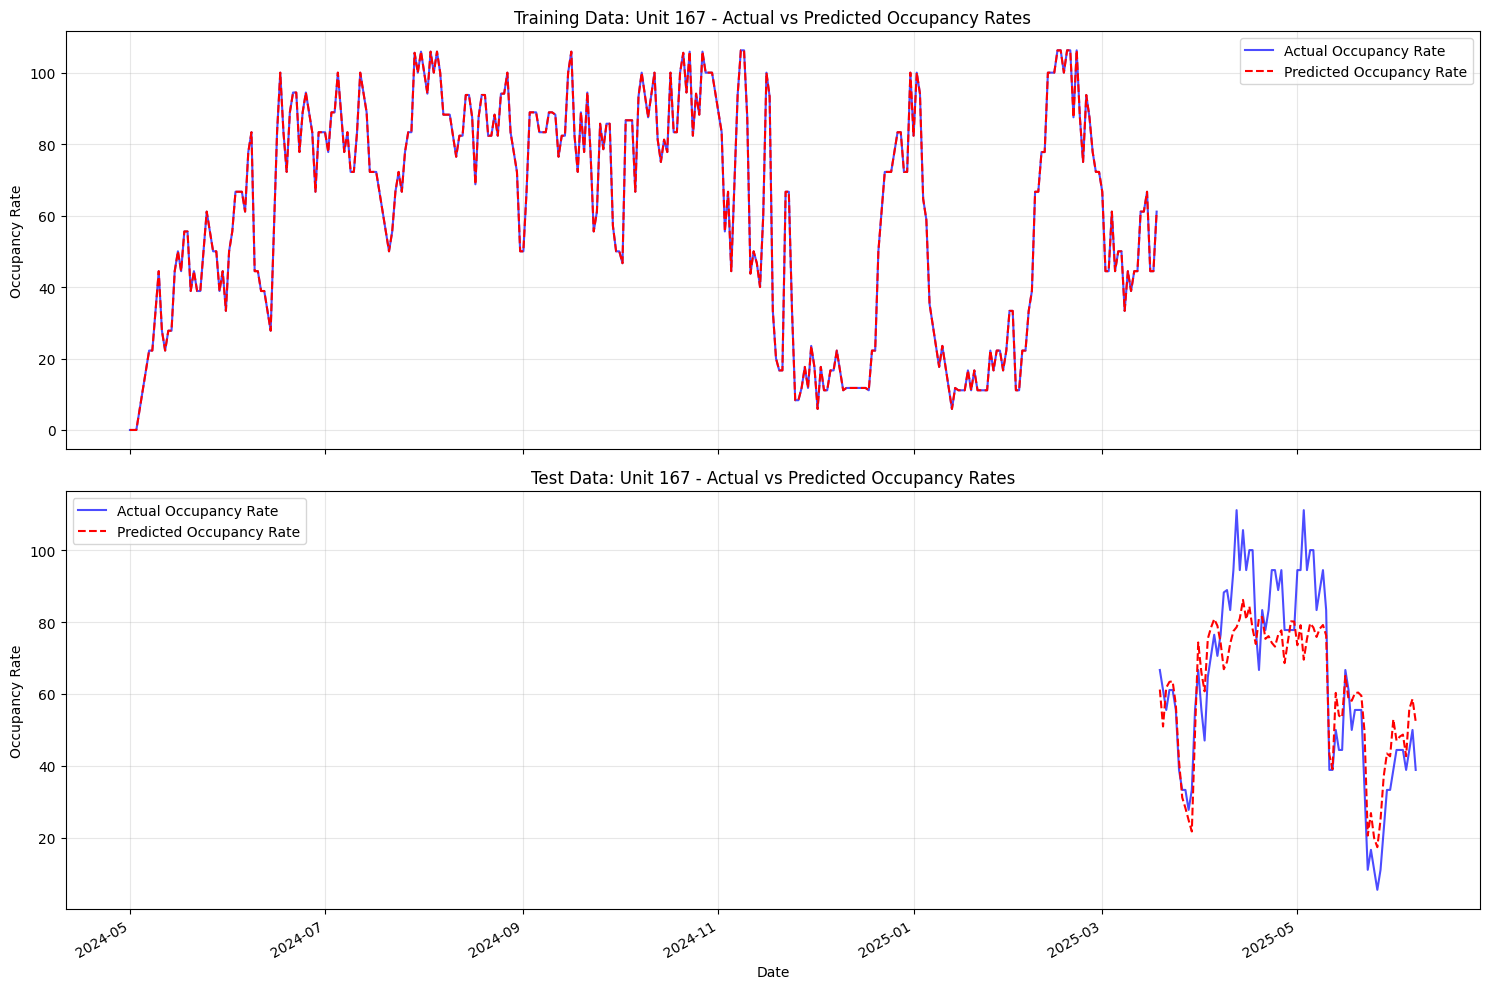

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: taux_occupation_167


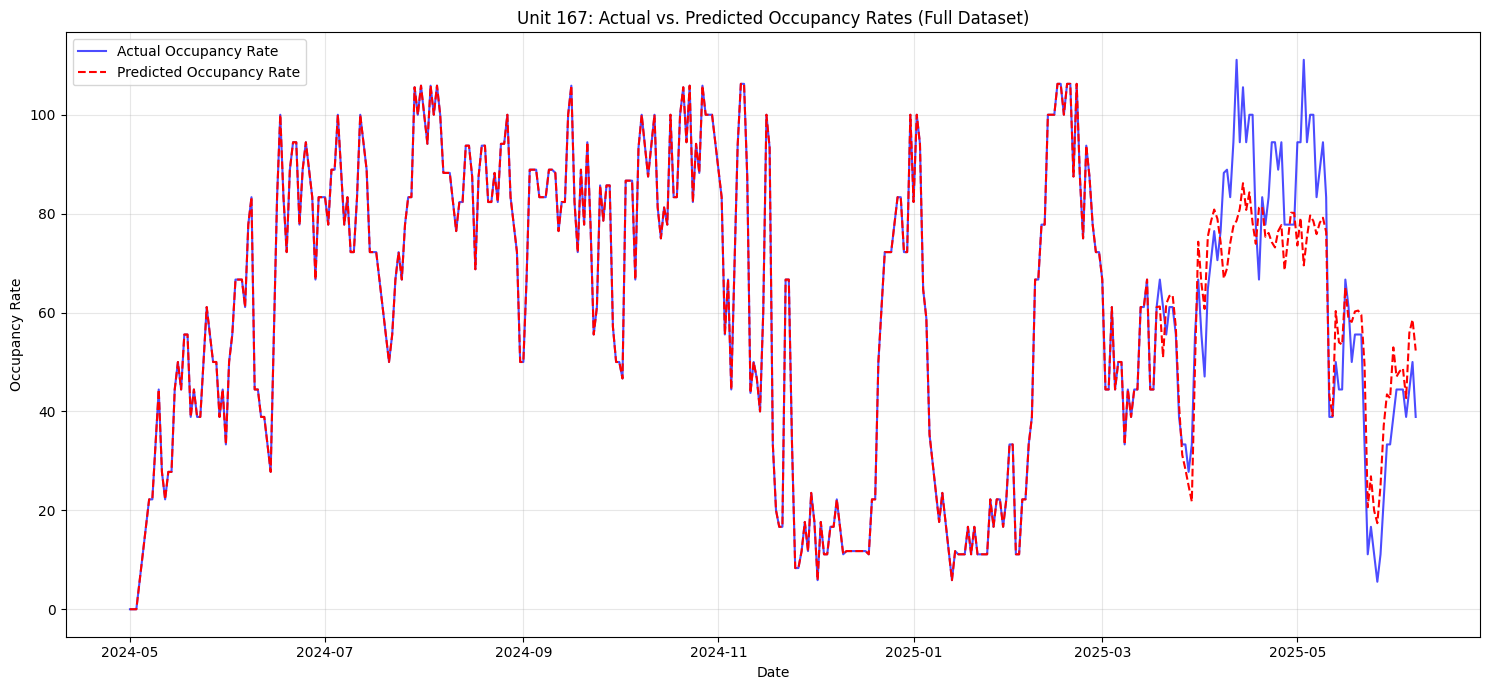


Pipeline finished for Unit 167 (target: taux).
--- End XGBoost Pipeline ---


In [19]:
xgb_results_taux_166 = run_xgboost_pipeline(
    df_166_weather,
    '166',
    test_size=0.2,
    target_type='taux',
    n_estimators=3000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
)

xgb_results_taux_167 = run_xgboost_pipeline(
    df_167_weather,
    '167',
    test_size=0.2,
    target_type='taux',
    n_estimators=3000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
)

In [20]:
save_xgboost_model(
    xgb_results=xgb_results_taux_166,
    folder_path=metadata['XGBoostModelsV3']['taux_166']['folder_path'],
    model_name=metadata['XGBoostModelsV3']['taux_166']['model_name'],
)

save_xgboost_model(
    xgb_results=xgb_results_taux_167,
    folder_path=metadata['XGBoostModelsV3']['taux_167']['folder_path'],
    model_name=metadata['XGBoostModelsV3']['taux_167']['model_name'],
)

Created directory: ../TrainedModels/UnitsBasedModelsV3/PredictTaux/XGBoostModels
Model successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/XGBoostModels\xgboost_v3_model_taux_166.pkl
Model successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/XGBoostModels\xgboost_v3_model_taux_167.pkl


'../TrainedModels/UnitsBasedModelsV3/PredictTaux/XGBoostModels\\xgboost_v3_model_taux_167.pkl'

--- Starting XGBoost Pipeline for Unit 166 ---
Target type: price

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_166
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: total_price_166
Hyperparameters: n_estimators=3000, lr=0.01, max_depth=20
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set size: 322 samples
Testing set size: 81 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 1.42
Test RMSE: 67104.39
Train MAE: 1.06
Test MAE: 51920.52
Train R²: 1.0000
Test R²: 0.3472

Feature Importance:
                Feature  Importance
7   

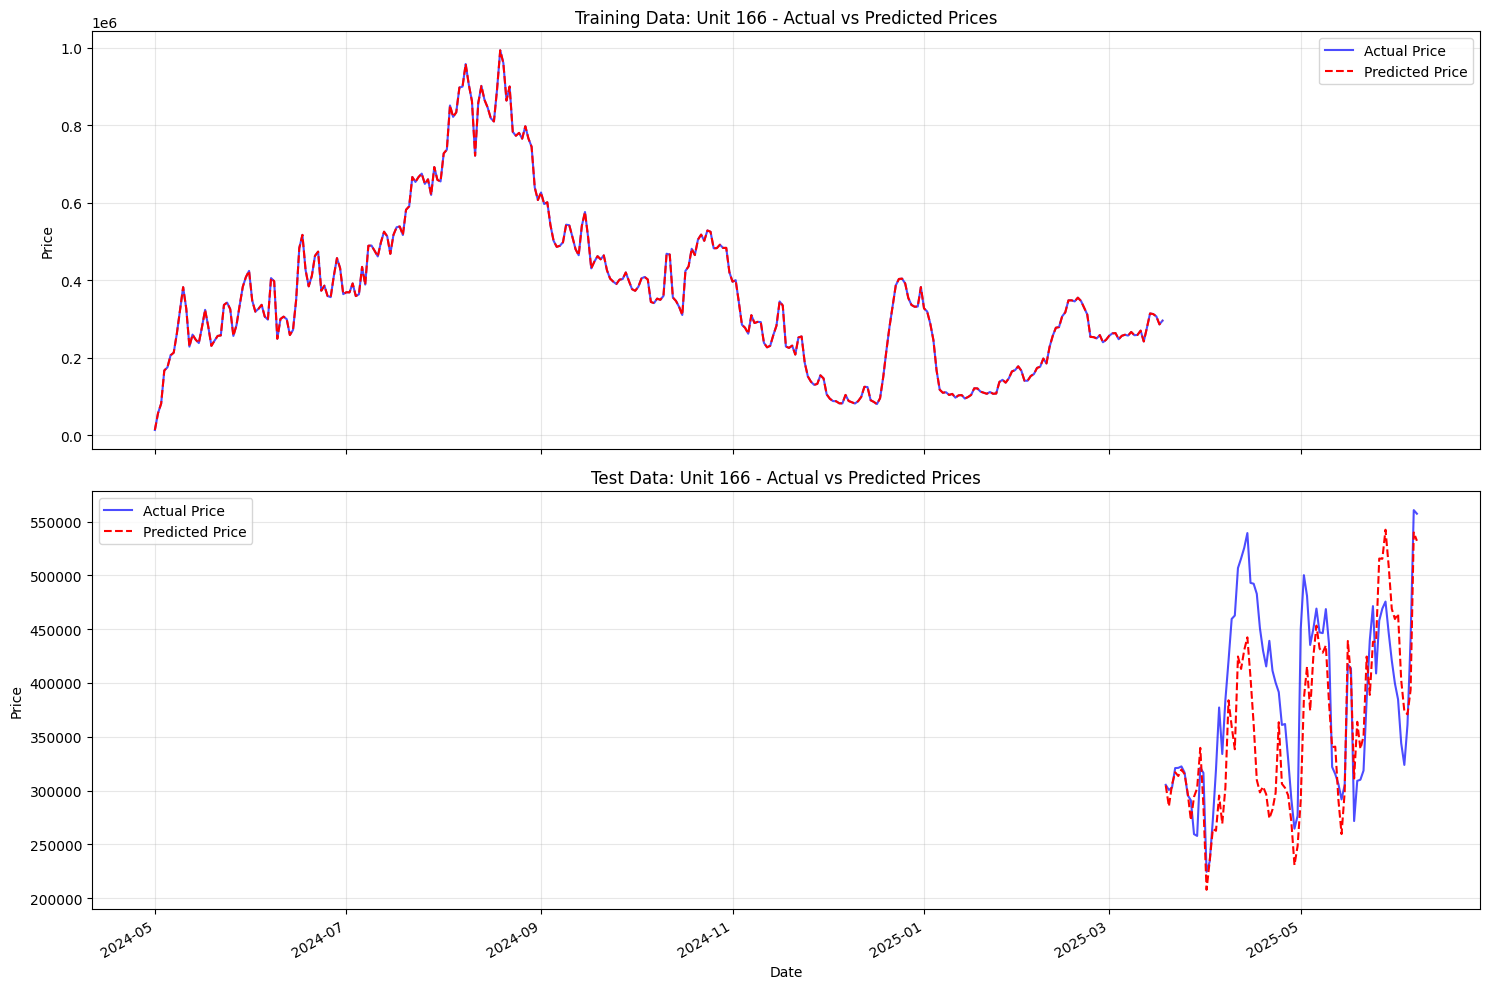

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: total_price_166


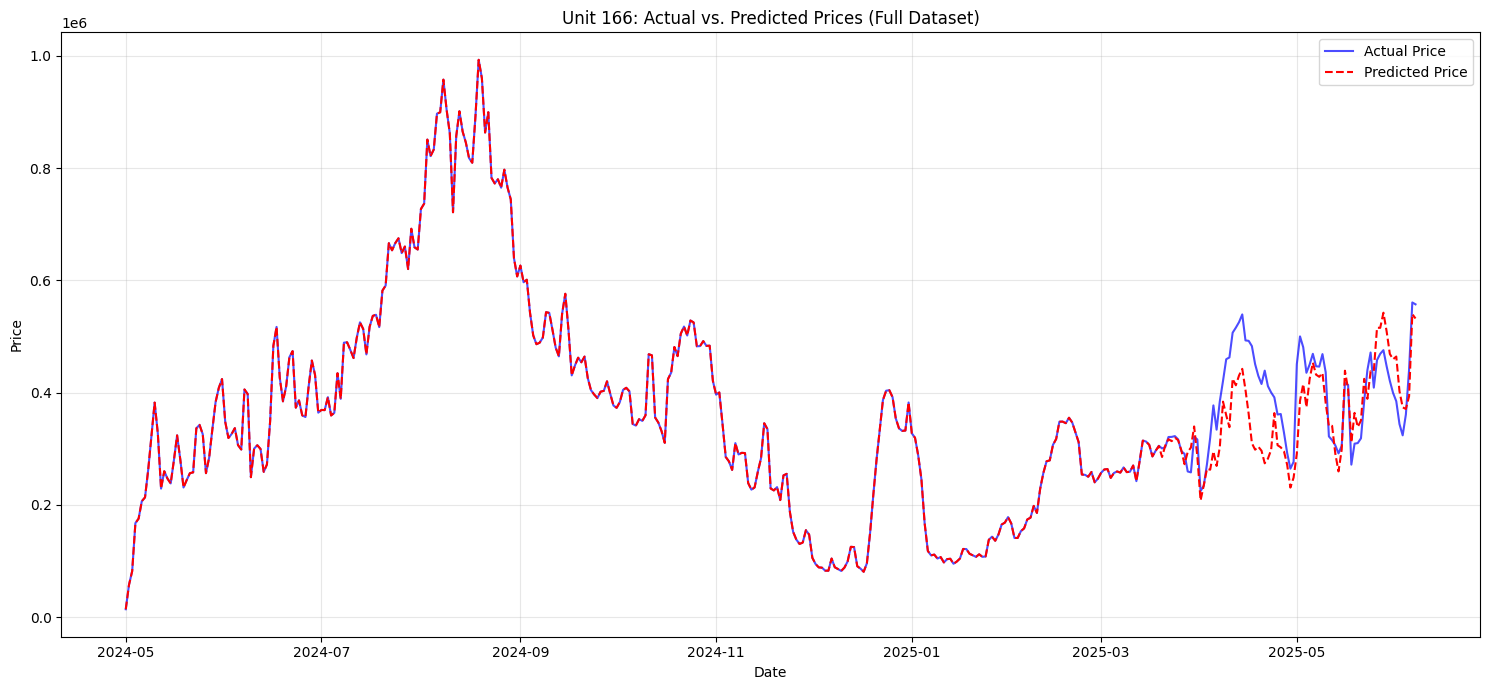


Pipeline finished for Unit 166 (target: price).
--- End XGBoost Pipeline ---
--- Starting XGBoost Pipeline for Unit 167 ---
Target type: price

[Step 1/3] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_167
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: total_price_167
Hyperparameters: n_estimators=3000, lr=0.01, max_depth=20
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set size: 322 samples
Testing set size: 81 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 0.10
Test RMSE: 7204.44
Train MAE: 0.06
Test MAE: 5921.19
Train R²: 1.0000
T

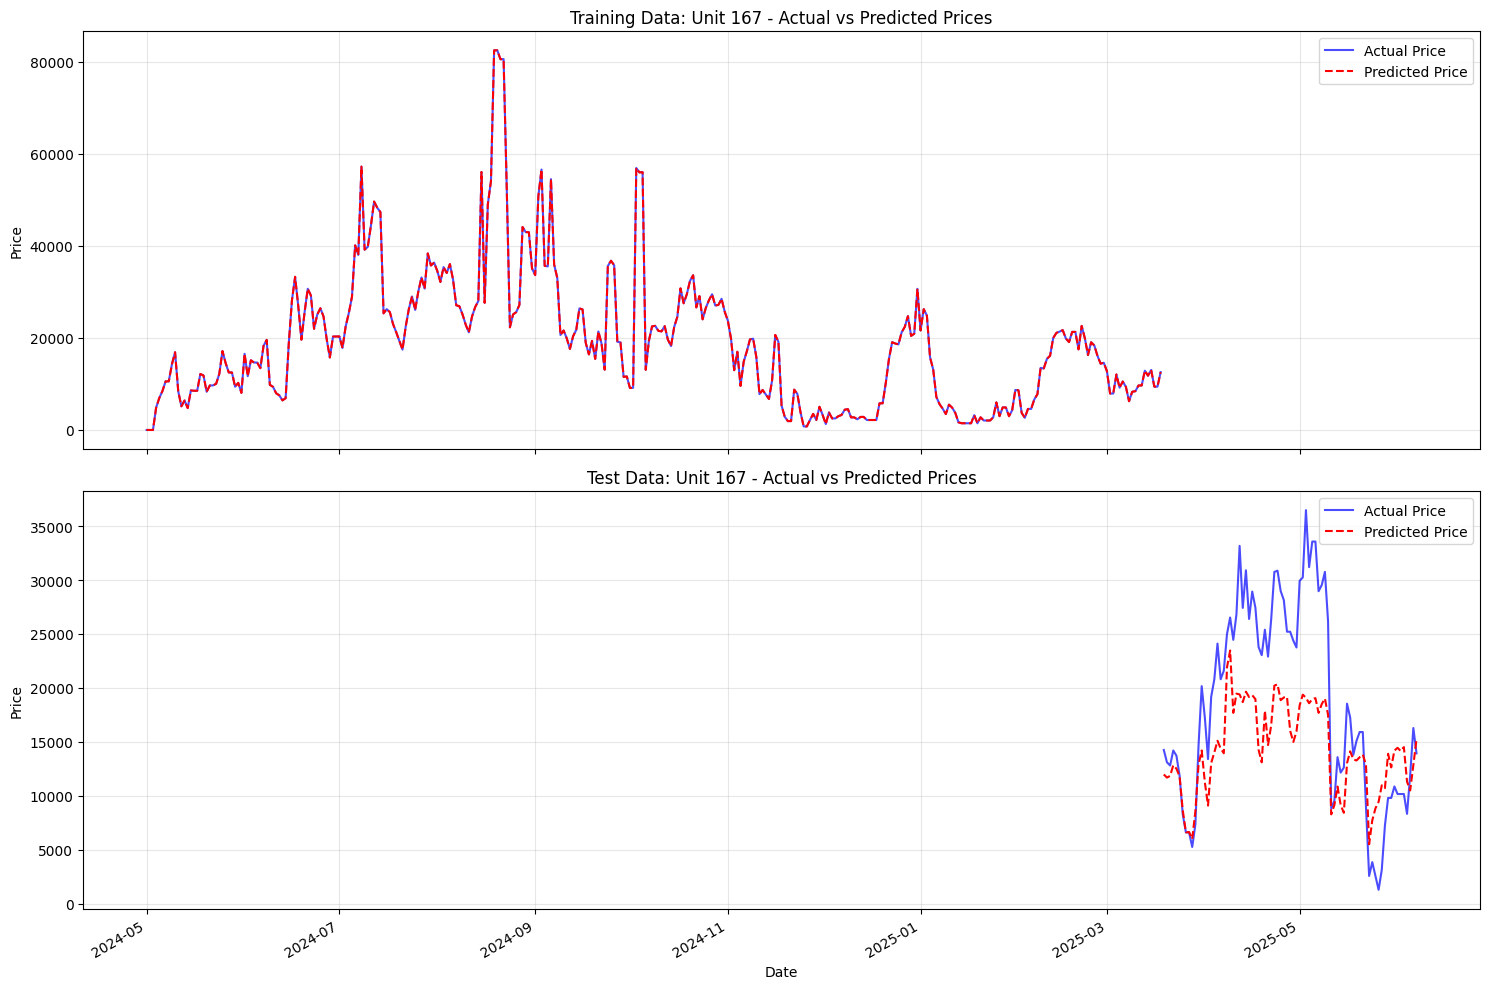

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: total_price_167


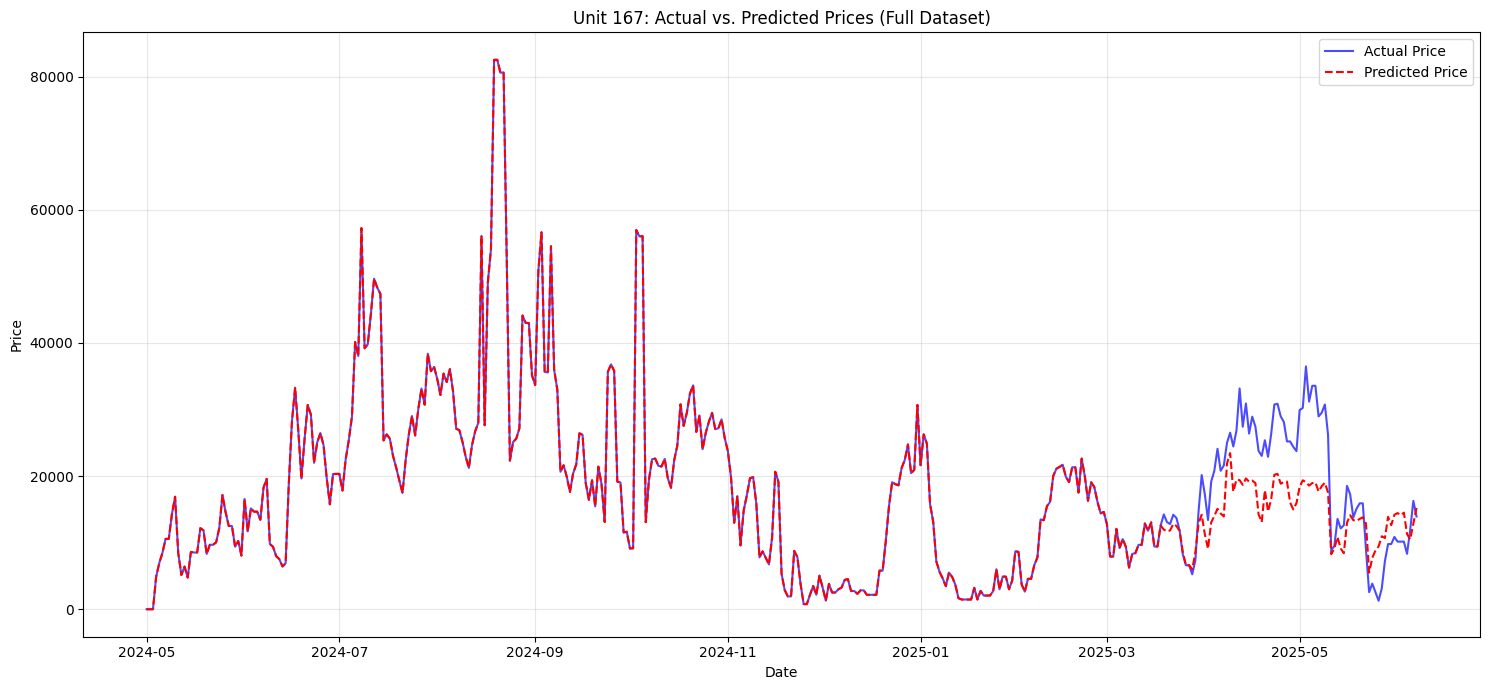


Pipeline finished for Unit 167 (target: price).
--- End XGBoost Pipeline ---


In [21]:
xgb_results_price_166 = run_xgboost_pipeline(
    df_166_weather,
    '166',
    test_size=0.2,
    target_type='price',
    n_estimators=3000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
)

xgb_results_price_167 = run_xgboost_pipeline(
    df_167_weather,
    '167',
    test_size=0.2,
    target_type='price',
    n_estimators=3000,
    max_depth=20,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
)

In [22]:
save_xgboost_model(
    xgb_results=xgb_results_price_166,
    folder_path=metadata['XGBoostModelsV3']['price_166']['folder_path'],
    model_name=metadata['XGBoostModelsV3']['price_166']['model_name'],
)

save_xgboost_model(
    xgb_results=xgb_results_price_167,
    folder_path=metadata['XGBoostModelsV3']['price_167']['folder_path'],
    model_name=metadata['XGBoostModelsV3']['price_167']['model_name'],
)

Created directory: ../TrainedModels/UnitsBasedModelsV3/PredictPrice/XGBoostModels
Model successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictPrice/XGBoostModels\xgboost_v3_model_166.pkl
Model successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictPrice/XGBoostModels\xgboost_v3_model_167.pkl


'../TrainedModels/UnitsBasedModelsV3/PredictPrice/XGBoostModels\\xgboost_v3_model_167.pkl'

In [7]:
xgboost_results = find_max_price_for_date_range_xgboost(
    start_date_str='2025-04-20',
    end_date_str='2025-04-25',
    unit_id='166',
    min_value=30.0,
    max_value=120.0,
    step=1,
    target_type='price',
    modelsName='XGBoostModelsV3',
    weather_data_dict= weather_data_dict
)

Loading model for target='price', unit='166'...
Model name: xgboost_v3_model_166
XGBoost model successfully loaded from ../TrainedModels/UnitsBasedModelsV3/PredictPrice/XGBoostModels\xgboost_v3_model_166.pkl
Model loaded successfully.

Searching for optimal taux for XGBoost model (unit 166) on 2025-04-20...
Target: Maximize price
Range: 30.0-120.0, step: 1


Testing XGBoost taux values:   3%|▎         | 3/91 [00:00<00:03, 29.32it/s]

Weather data successfully retrieved from pre-loaded data for 2025-04-20

Predicting total_price_166 with XGBoost for Unit 166 on 2025-04-20
Features used:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          6      4  2025        110          16                 30.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           22.226           12.776            16.818            0.0   

   windspeed_max  temperature_range  
0         13.259               9.45  
Predicted total_price_166: 143007.39
Weather data successfully retrieved from pre-loaded data for 2025-04-20

Predicting total_price_166 with XGBoost for Unit 166 on 2025-04-20
Features used:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          6      4  2025        110          16                 31.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           22.226           12.776            16.818            0

Testing XGBoost taux values:  12%|█▏        | 11/91 [00:00<00:02, 30.41it/s]

Predicted total_price_166: 159816.05
Weather data successfully retrieved from pre-loaded data for 2025-04-20

Predicting total_price_166 with XGBoost for Unit 166 on 2025-04-20
Features used:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          6      4  2025        110          16                 37.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           22.226           12.776            16.818            0.0   

   windspeed_max  temperature_range  
0         13.259               9.45  
Predicted total_price_166: 159816.05
Weather data successfully retrieved from pre-loaded data for 2025-04-20

Predicting total_price_166 with XGBoost for Unit 166 on 2025-04-20
Features used:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          6      4  2025        110          16                 38.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           22.226           

...

Predicted total_price_166: 444974.97
Weather data successfully retrieved from pre-loaded data for 2025-04-25

Predicting total_price_166 with XGBoost for Unit 166 on 2025-04-25
Features used:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          4      4  2025        115          17                108.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           27.176           16.276             20.07           10.2   

   windspeed_max  temperature_range  
0          19.03               10.9  
Predicted total_price_166: 444974.97
Weather data successfully retrieved from pre-loaded data for 2025-04-25

Predicting total_price_166 with XGBoost for Unit 166 on 2025-04-25
Features used:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          4      4  2025        115          17                109.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           27.176           

Testing XGBoost taux values:  97%|█████████▋| 88/91 [00:02<00:00, 31.09it/s]

Weather data successfully retrieved from pre-loaded data for 2025-04-25

Predicting total_price_166 with XGBoost for Unit 166 on 2025-04-25
Features used:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          4      4  2025        115          17                114.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           27.176           16.276             20.07           10.2   

   windspeed_max  temperature_range  
0          19.03               10.9  
Predicted total_price_166: 444974.97
Weather data successfully retrieved from pre-loaded data for 2025-04-25

Predicting total_price_166 with XGBoost for Unit 166 on 2025-04-25
Features used:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166  \
0          4      4  2025        115          17                115.0   

   temperature_max  temperature_min  temperature_mean  precipitation  \
0           27.176           16.276             20.07           10

Testing XGBoost taux values: 100%|██████████| 91/91 [00:02<00:00, 30.34it/s]

Predicted total_price_166: 444974.97

XGBoost Search complete. Optimal taux_occupation: 101.00 -> 
Max Price: 447102.53


In [8]:
xgboost_results

{'2025-04-20': {'best_input': 101.0, 'max_output': 438105.46875},
 '2025-04-21': {'best_input': 101.0, 'max_output': 421764.3125},
 '2025-04-22': {'best_input': 101.0, 'max_output': 443586.0},
 '2025-04-23': {'best_input': 101.0, 'max_output': 446790.46875},
 '2025-04-24': {'best_input': 101.0, 'max_output': 469659.40625},
 '2025-04-25': {'best_input': 101.0, 'max_output': 447102.53125}}

### Train the LSTM models on the **weather data**

--- Starting LSTM Pipeline for Unit 166 (predicting Occupancy Rate) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_166
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: taux_occupation_166 (predicting Occupancy Rate)
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']

Starting Training...


Epoch [10/80], Loss: 0.067276


Epoch [20/80], Loss: 0.044957


Epoch [30/80], Loss: 0.037602


Epoch [40/80], Loss: 0.027932


Epoch [50/80], Loss: 0.025487


Epoch [60/80], Loss: 0.018313


Epoch [70/80], Loss: 0.016728


Epoch [80/80], Loss: 0.015338
Training Finished.

Model Evaluation Metrics for Occupancy Rate prediction:
Train RMSE: 9.99
Test RMSE: 17.83
Train MAE: 8.21
Test MAE: 15.59
Train R²: 0.7960
Test R²: -0.9603

[Step 3/4] Plotting results...
Plotting training loss...


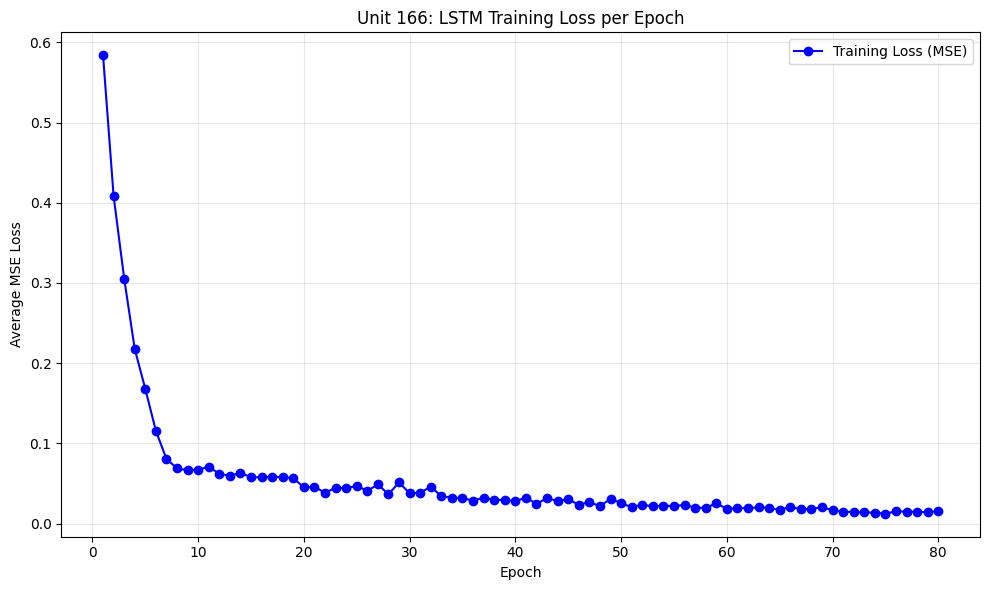

Plotting predictions on train/test split...


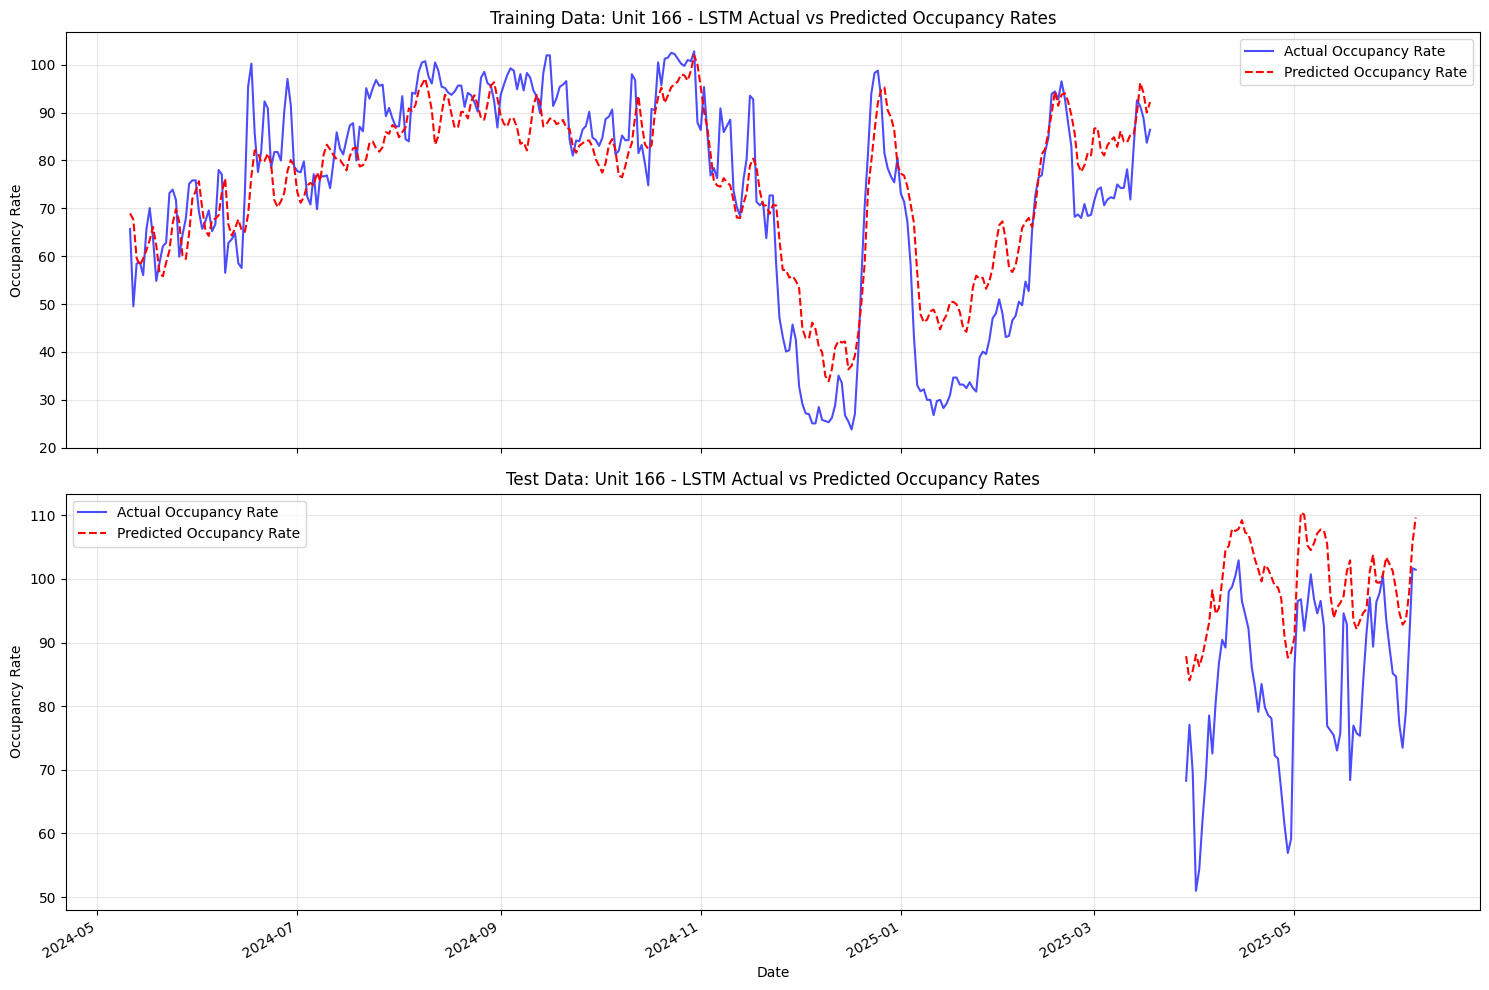

Plotting predictions on the full unit DataFrame...


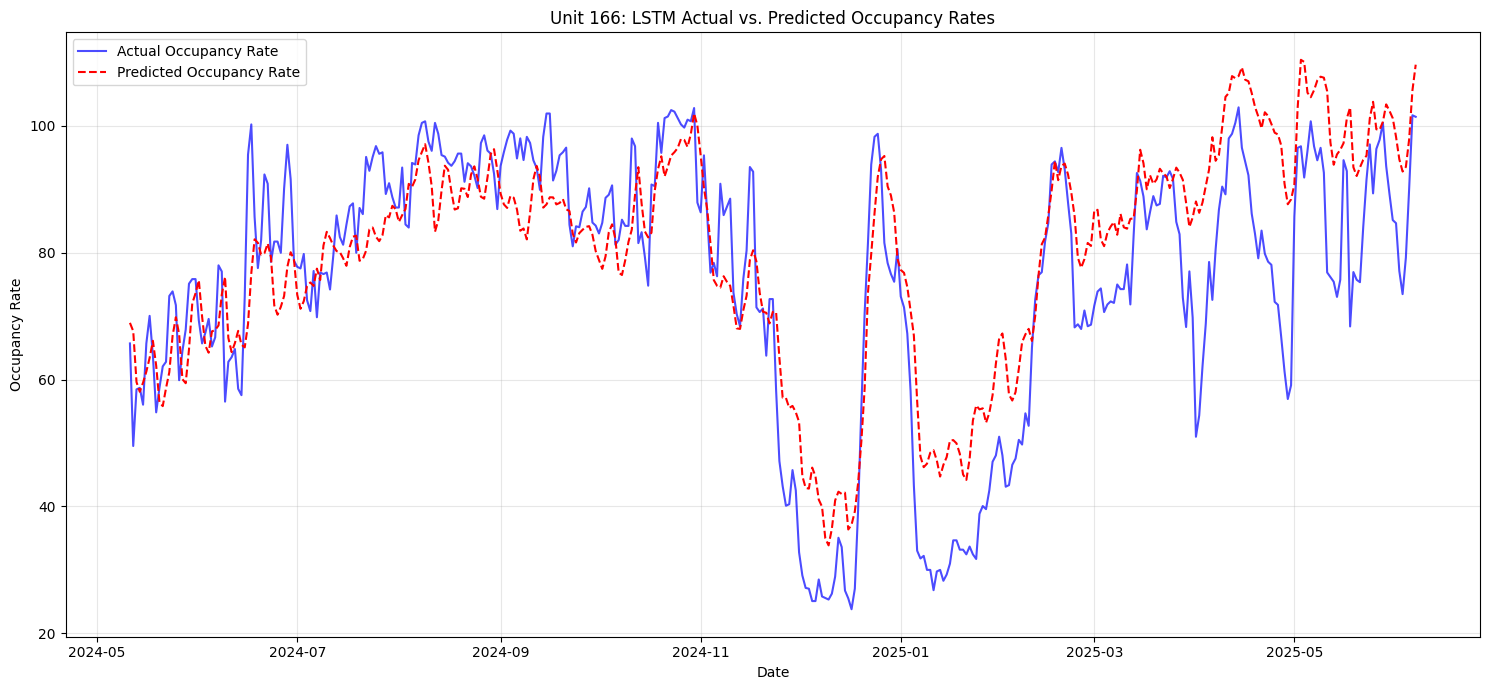


[Step 4/4] Pipeline finished for Unit 166.
--- End LSTM Pipeline ---
--- Starting LSTM Pipeline for Unit 167 (predicting Occupancy Rate) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: taux_occupation_167
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: taux_occupation_167 (predicting Occupancy Rate)
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_167', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']

Starting Training...


Epoch [10/80], Loss: 0.089586


Epoch [20/80], Loss: 0.069335


Epoch [30/80], Loss: 0.049929


Epoch [40/80], Loss: 0.054550


Epoch [50/80], Loss: 0.038233


Epoch [60/80], Loss: 0.030664


Epoch [70/80], Loss: 0.032535


Epoch [80/80], Loss: 0.030994
Training Finished.

Model Evaluation Metrics for Occupancy Rate prediction:
Train RMSE: 14.40
Test RMSE: 29.31
Train MAE: 11.23
Test MAE: 25.83
Train R²: 0.7684
Test R²: -0.1619

[Step 3/4] Plotting results...
Plotting training loss...


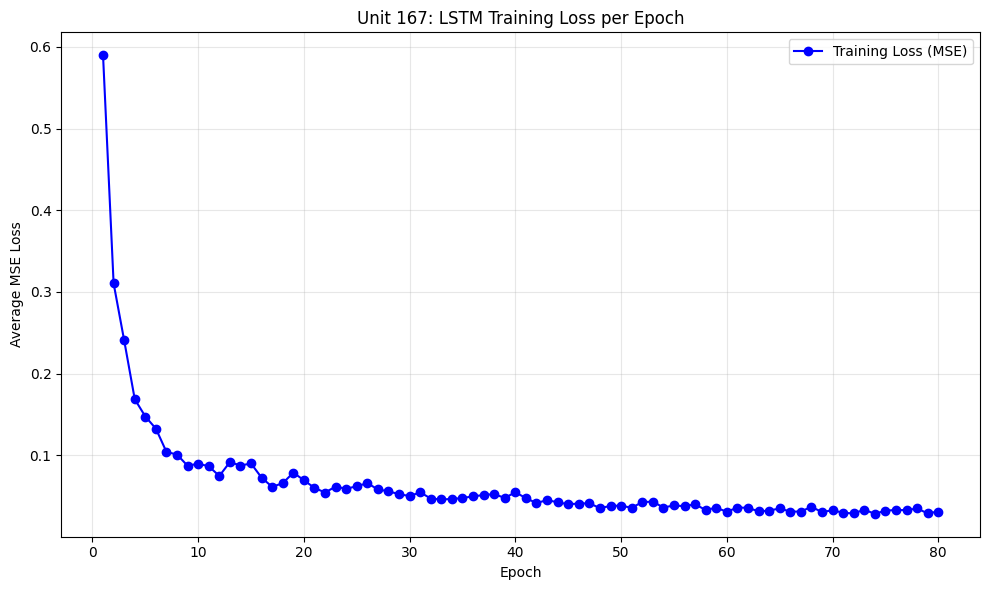

Plotting predictions on train/test split...


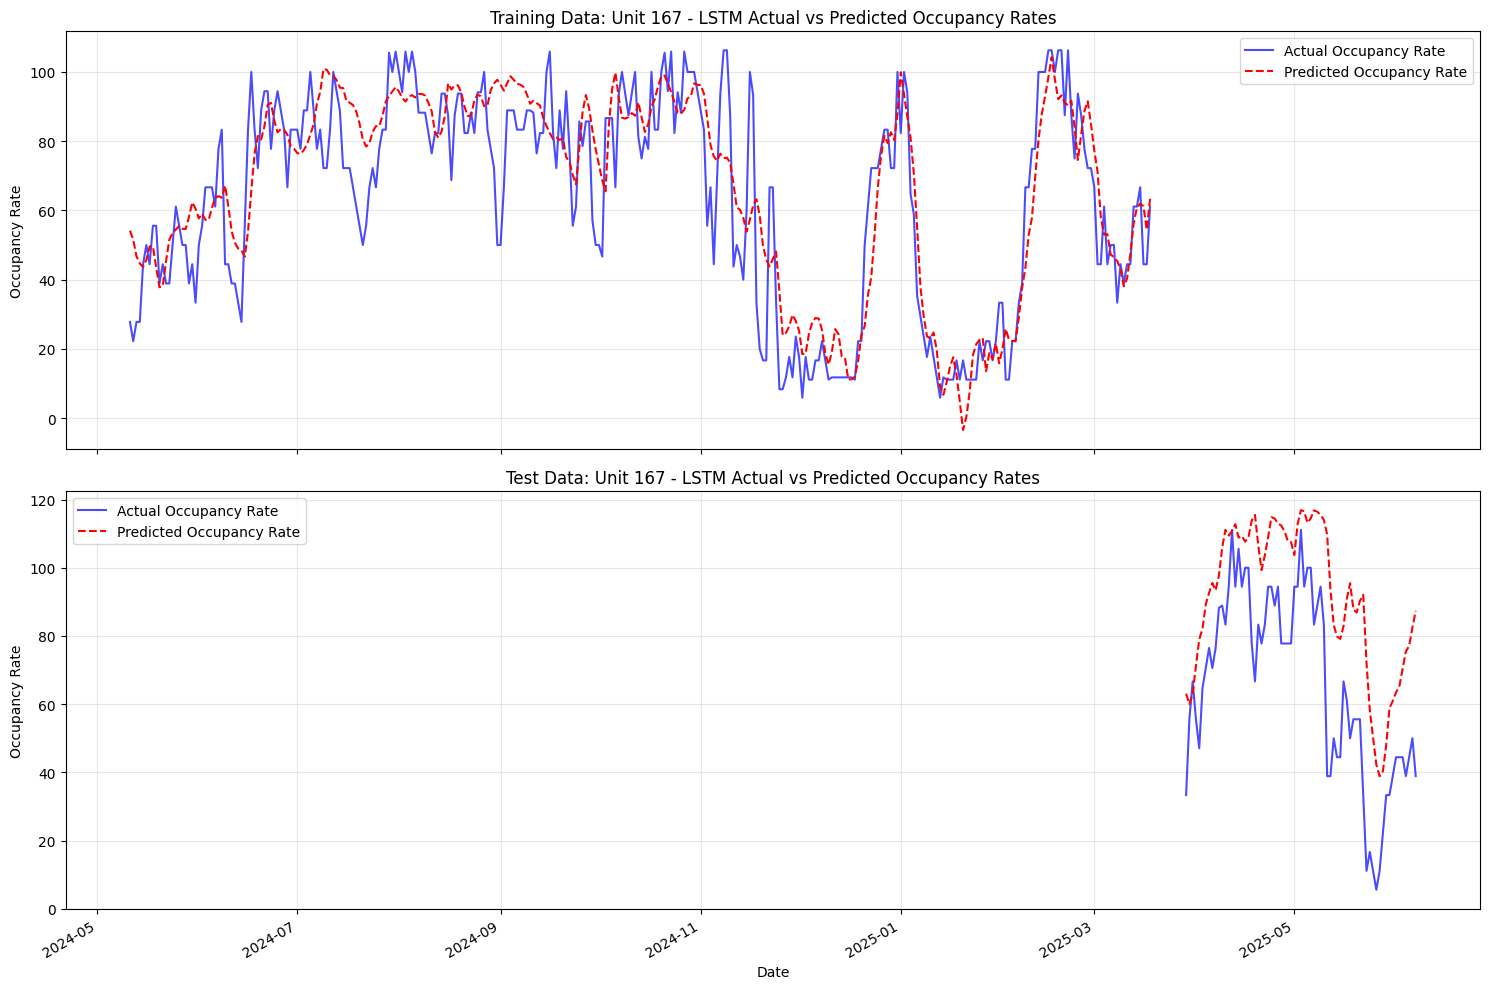

Plotting predictions on the full unit DataFrame...


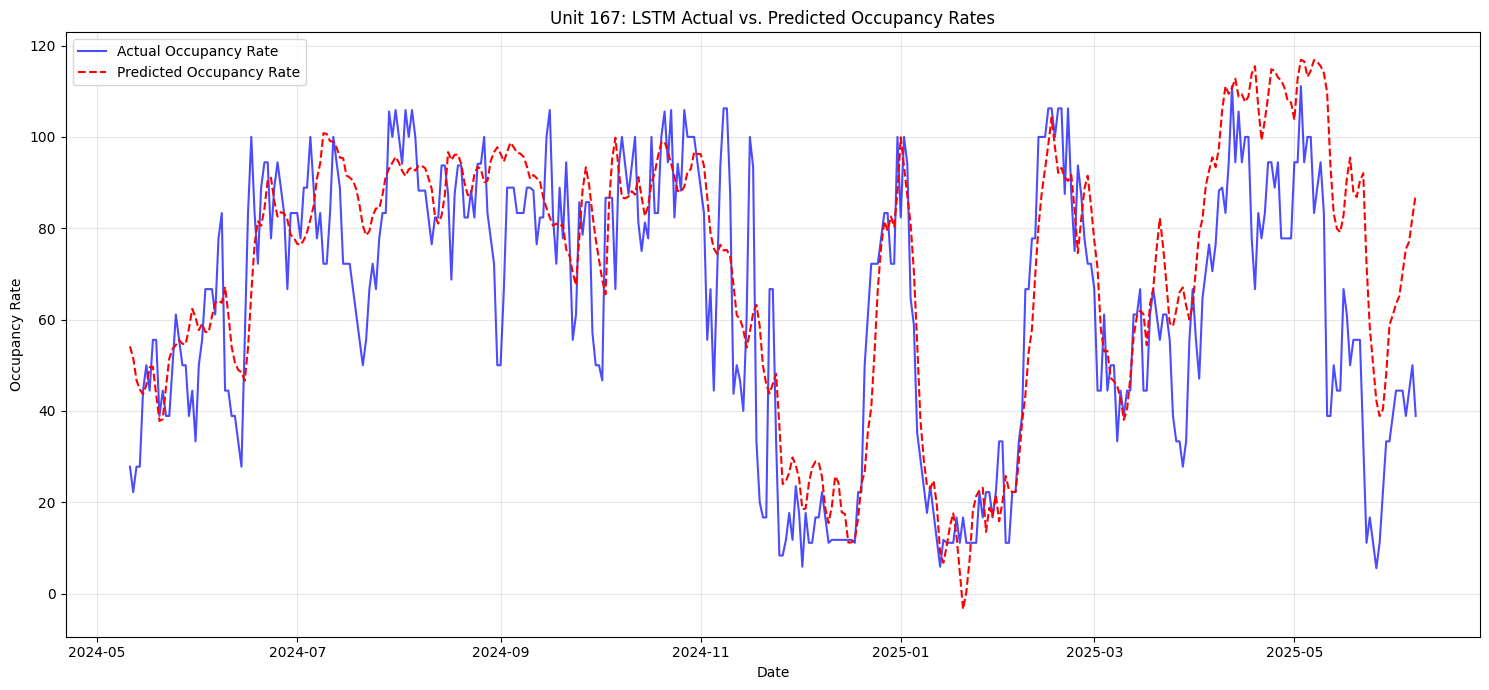


[Step 4/4] Pipeline finished for Unit 167.
--- End LSTM Pipeline ---


In [9]:
lstm_results_taux_166 = run_lstm_pipeline(
    df_166_weather,
    '166',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
    target_type='taux'
)

lstm_results_taux_167 = run_lstm_pipeline(
    df_167_weather,
    '167',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
    target_type='taux'
)

In [10]:
save_lstm_model(
    lstm_results=lstm_results_taux_166,
    folder_path=metadata['LSTMModelsV3']['taux_166']['folder_path'],
    model_name=metadata['LSTMModelsV3']['taux_166']['model_name'],
)

save_lstm_model(
    lstm_results=lstm_results_taux_167,
    folder_path=metadata['LSTMModelsV3']['taux_167']['folder_path'],
    model_name=metadata['LSTMModelsV3']['taux_167']['model_name'],
)

Created directory: ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels
Model state dictionary successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels\lstm_v3_model_166_taux_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels\lstm_v3_model_166_taux_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels\lstm_v3_model_166_taux_target_scaler.pkl
Model metadata saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels\lstm_v3_model_166_taux_metadata.json
Model state dictionary successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels\lstm_v3_model_167_taux_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels\lstm_v3_model_167_taux_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels

{'model_state_dict': '../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels\\lstm_v3_model_167_taux_model_state_dict.pth',
 'feature_scaler': '../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels\\lstm_v3_model_167_taux_feature_scaler.pkl',
 'target_scaler': '../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels\\lstm_v3_model_167_taux_target_scaler.pkl',
 'metadata': '../TrainedModels/UnitsBasedModelsV3/PredictTaux/LSTMModels\\lstm_v3_model_167_taux_metadata.json'}

--- Starting LSTM Pipeline for Unit 166 (predicting Price) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_166
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: total_price_166 (predicting Price)
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']

Starting Training...


Epoch [10/80], Loss: 0.042338


Epoch [20/80], Loss: 0.025655


Epoch [30/80], Loss: 0.020365


Epoch [40/80], Loss: 0.015645


Epoch [50/80], Loss: 0.014053


Epoch [60/80], Loss: 0.011674


Epoch [70/80], Loss: 0.010107


Epoch [80/80], Loss: 0.008480
Training Finished.

Model Evaluation Metrics for Price prediction:
Train RMSE: 64966.51
Test RMSE: 104648.77
Train MAE: 47554.77
Test MAE: 85258.77
Train R²: 0.9010
Test R²: -0.6302

[Step 3/4] Plotting results...
Plotting training loss...


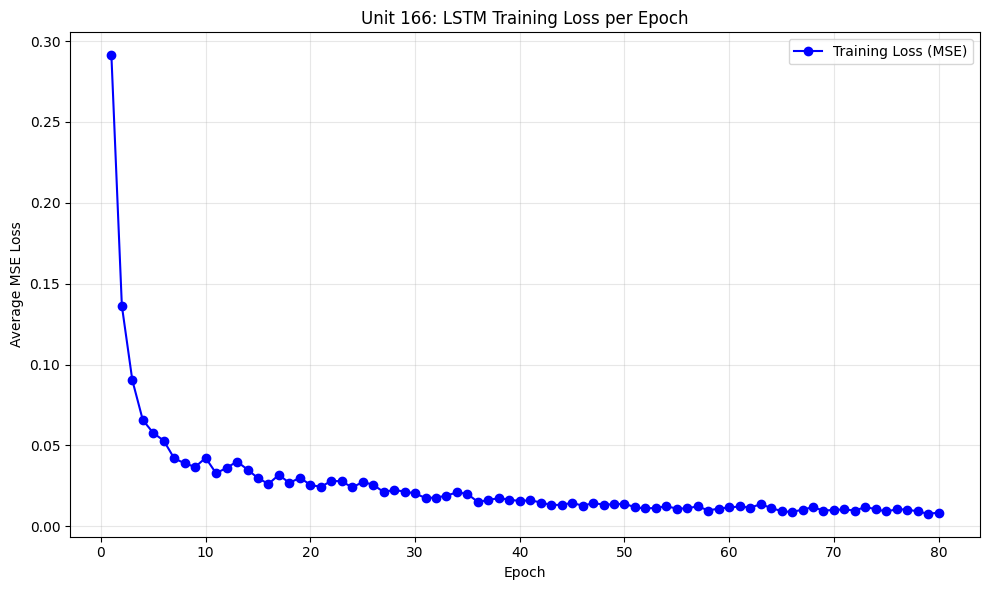

Plotting predictions on train/test split...


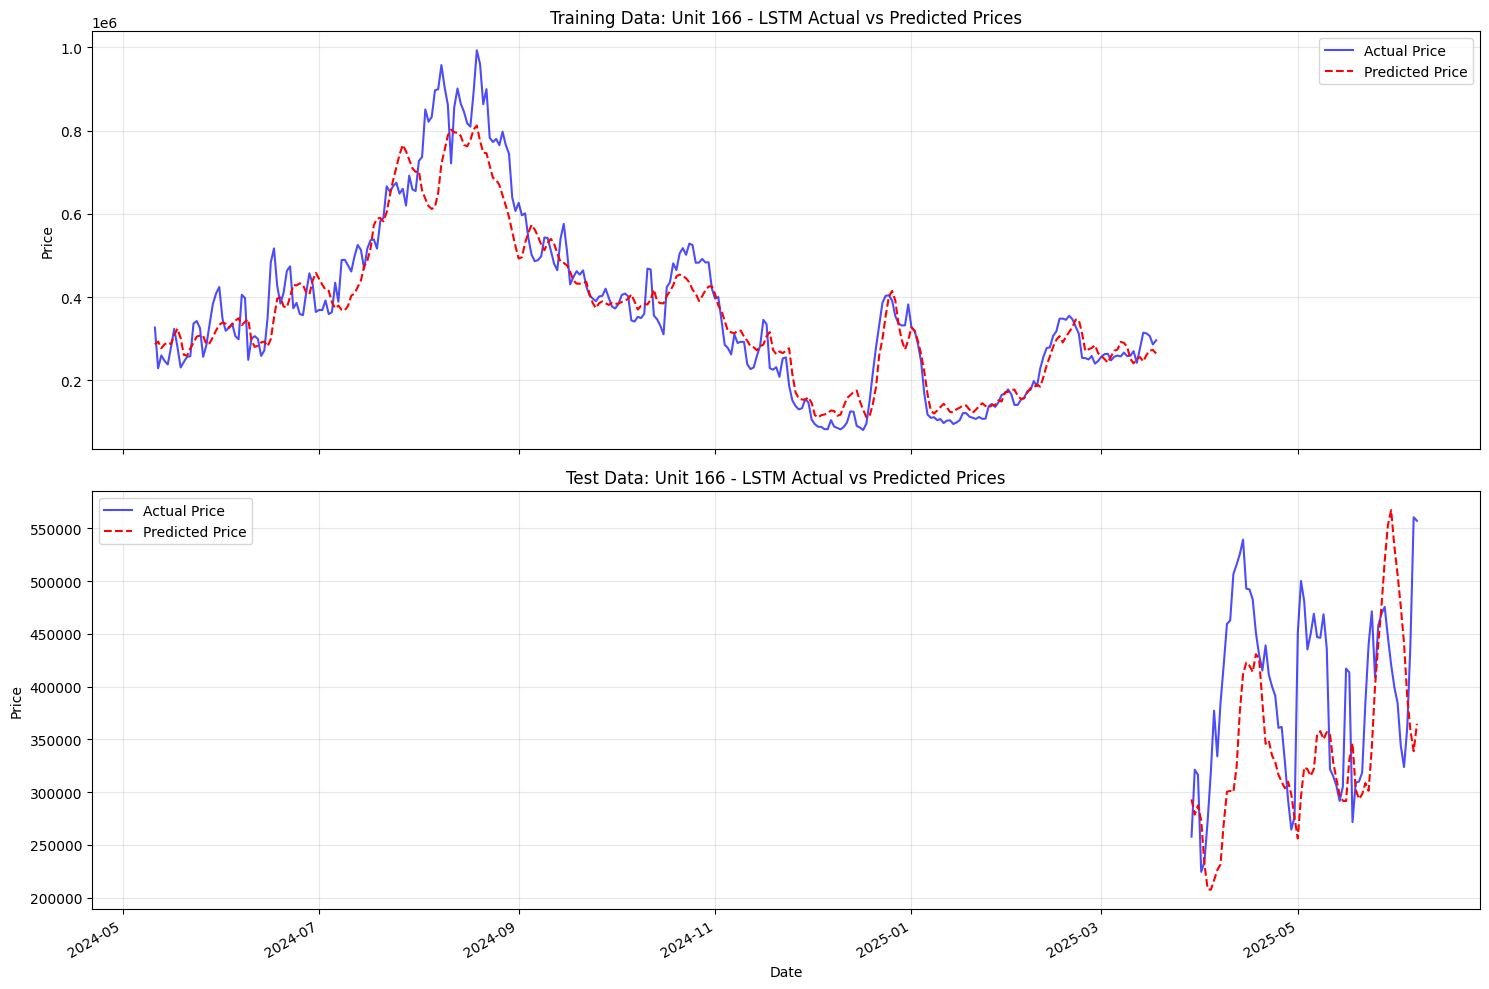

Plotting predictions on the full unit DataFrame...


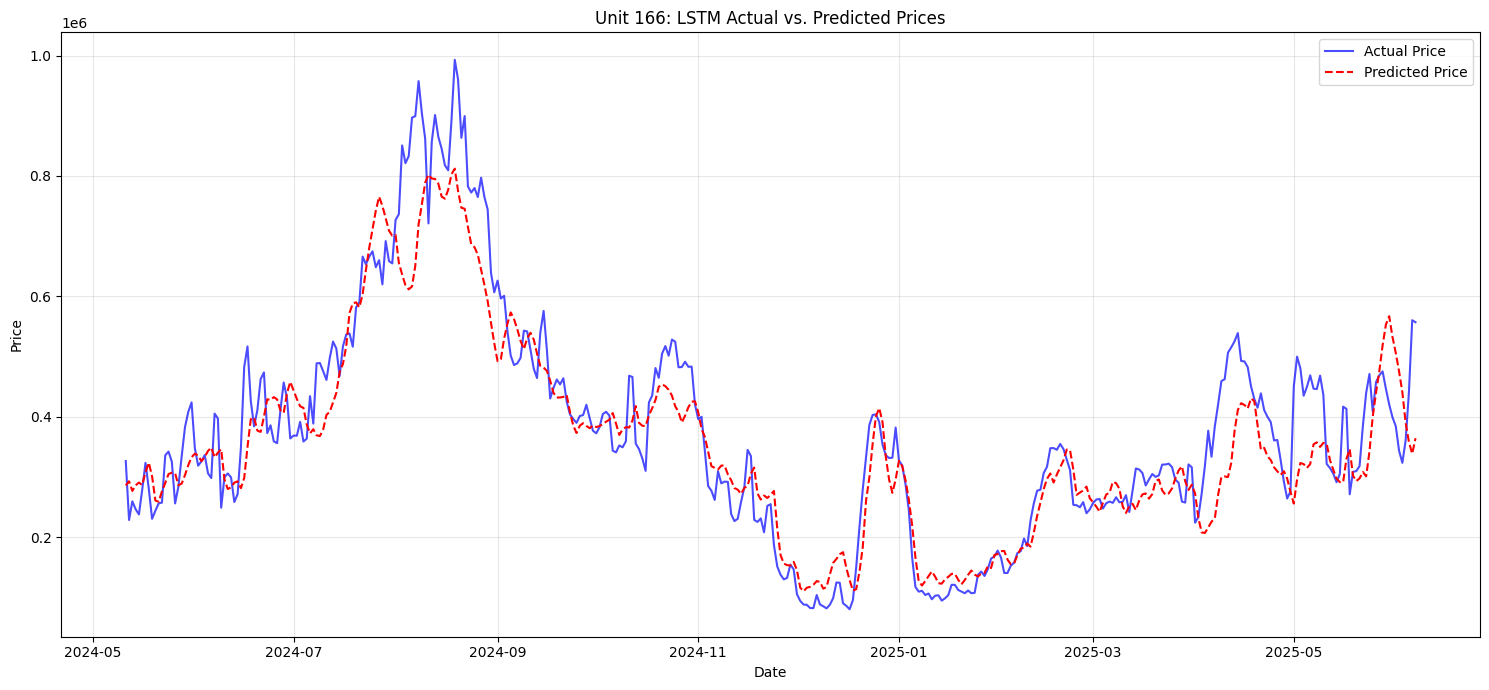


[Step 4/4] Pipeline finished for Unit 166.
--- End LSTM Pipeline ---
--- Starting LSTM Pipeline for Unit 167 (predicting Price) ---

[Step 1/4] Splitting data with test_size=0.2...
Split complete. Test size: 0.20
Target column: total_price_167
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing set range: 2025-03-19 00:00:00 to 2025-06-07 00:00:00 (81 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: total_price_167 (predicting Price)
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']

Starting Training...


Epoch [10/80], Loss: 0.034543


Epoch [20/80], Loss: 0.022703


Epoch [30/80], Loss: 0.022642


Epoch [40/80], Loss: 0.018936


Epoch [50/80], Loss: 0.016699


Epoch [60/80], Loss: 0.016129


Epoch [70/80], Loss: 0.017554


Epoch [80/80], Loss: 0.014721
Training Finished.

Model Evaluation Metrics for Price prediction:
Train RMSE: 9833.02
Test RMSE: 6903.02
Train MAE: 7341.81
Test MAE: 5511.39
Train R²: 0.5490
Test R²: 0.4262

[Step 3/4] Plotting results...
Plotting training loss...


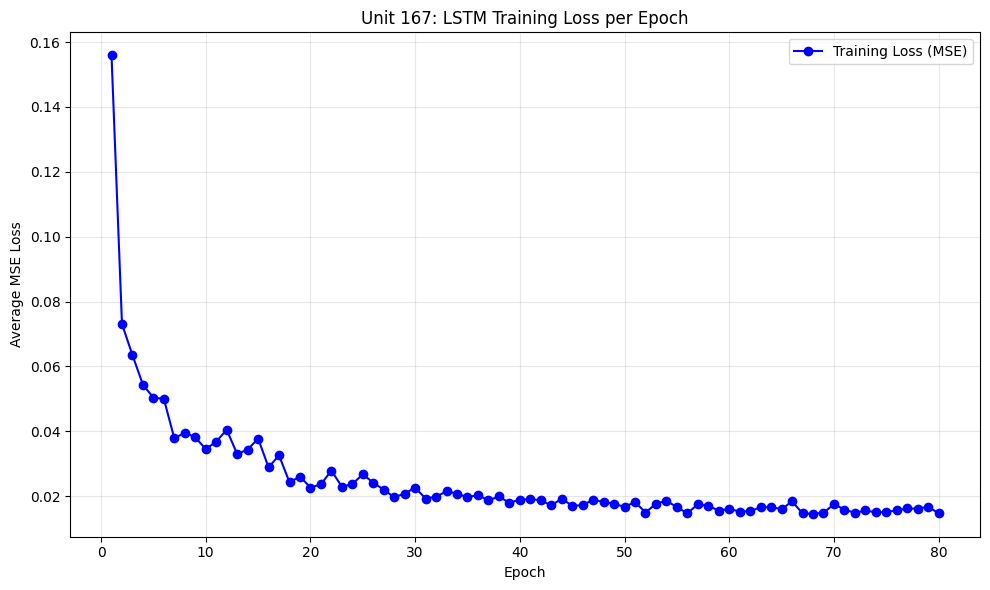

Plotting predictions on train/test split...


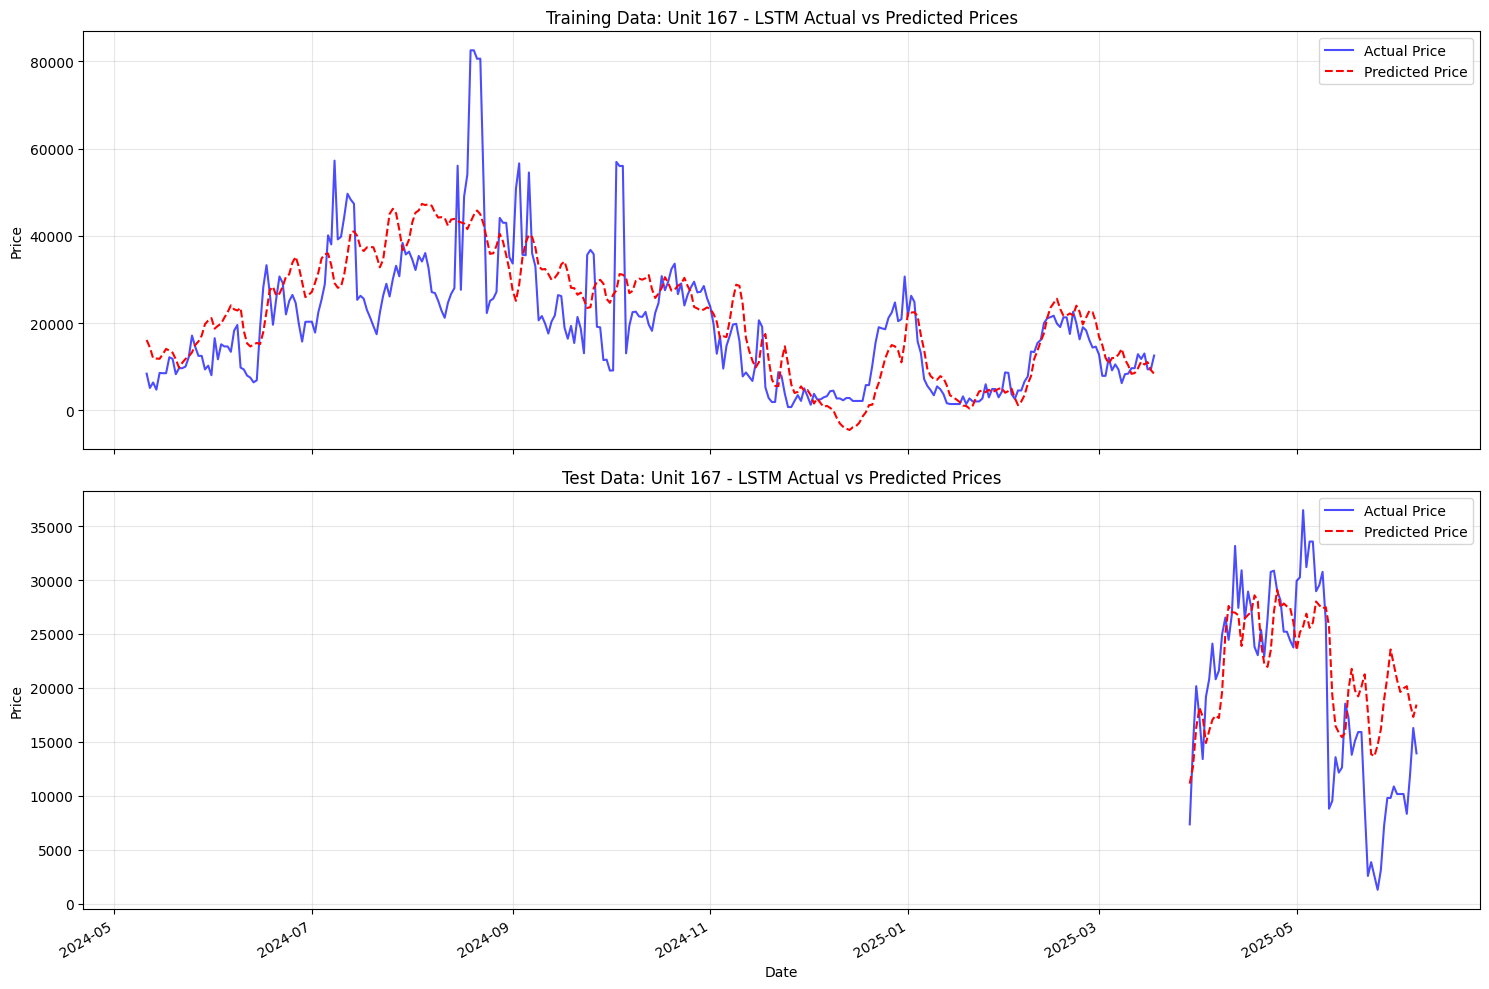

Plotting predictions on the full unit DataFrame...


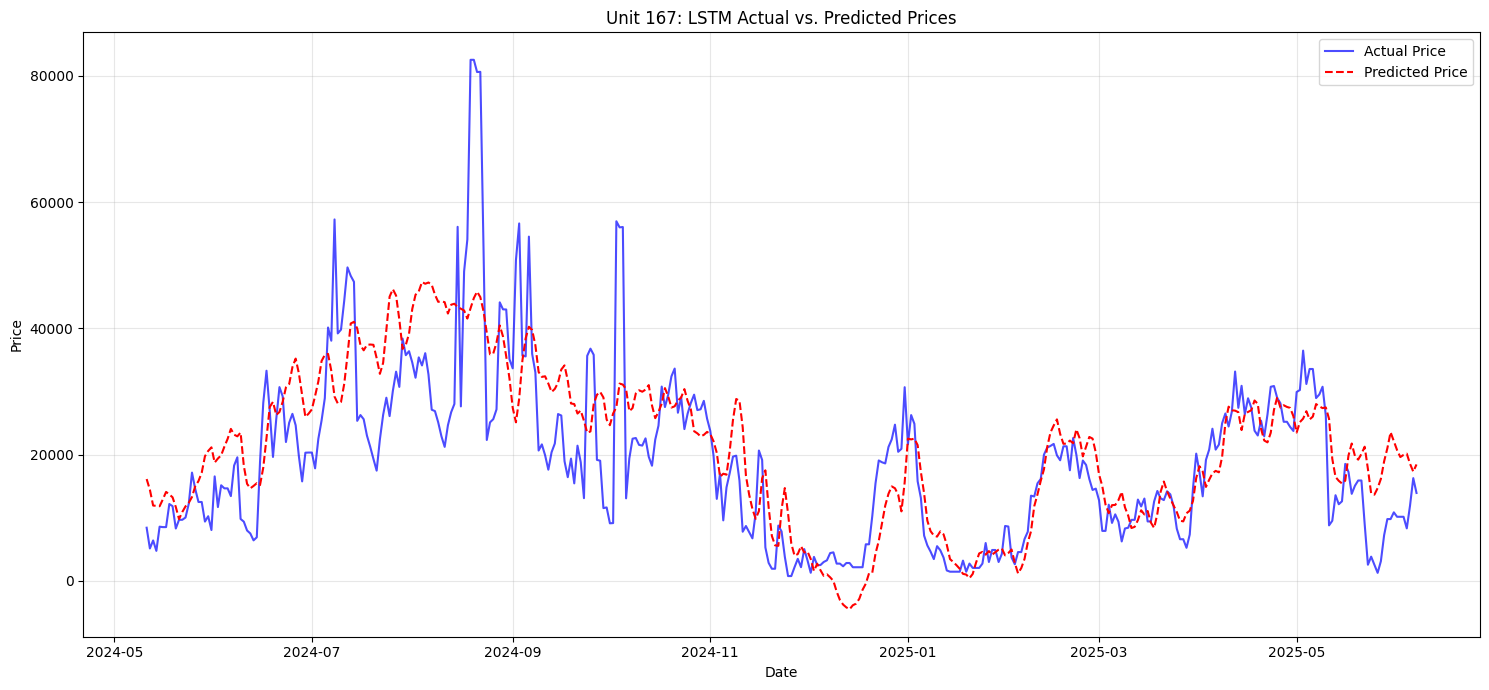


[Step 4/4] Pipeline finished for Unit 167.
--- End LSTM Pipeline ---


In [11]:
lstm_results_price_166 = run_lstm_pipeline(
    df_166_weather,
    '166',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
    target_type='price'
)

lstm_results_price_167 = run_lstm_pipeline(
    df_167_weather,
    '167',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
    target_type='price'
)

In [12]:
save_lstm_model(
    lstm_results=lstm_results_price_166,
    folder_path=metadata['LSTMModelsV3']['price_166']['folder_path'],
    model_name=metadata['LSTMModelsV3']['price_166']['model_name'],
)

save_lstm_model(
    lstm_results=lstm_results_price_167,
    folder_path=metadata['LSTMModelsV3']['price_167']['folder_path'],
    model_name=metadata['LSTMModelsV3']['price_167']['model_name'],
)

Created directory: ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels
Model state dictionary successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_target_scaler.pkl
Model metadata saved to ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_metadata.json
Model state dictionary successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_167_price_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_167_price_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels/UnitsBasedModelsV3/PredictPr

{'model_state_dict': '../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\\lstm_v3_model_167_price_model_state_dict.pth',
 'feature_scaler': '../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\\lstm_v3_model_167_price_feature_scaler.pkl',
 'target_scaler': '../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\\lstm_v3_model_167_price_target_scaler.pkl',
 'metadata': '../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\\lstm_v3_model_167_price_metadata.json'}

In [13]:
results_lstm = find_max_output_for_date_range_lstm(
    start_date_str='2025-04-20',
    end_date_str='2025-04-30',
    unit_id='166',
    min_value=30.0,
    max_value=100.0,
    step=1,
    df_166=df_166_weather,
    df_167=df_167_weather,
    target_type='price',
    modelsName='LSTMModelsV3',
    weather_data_dict=weather_data_dict
)


Processing date: 2025-04-20 for LSTM...
Loading model for target='price', unit='166'...
Model name: lstm_v3_model_166_price
Metadata successfully loaded from ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_metadata.json
Target column extracted: total_price_166
Target type extracted: price
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_model_state_dict.pth onto cpu
Feature scaler successfully loaded from ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_target_scaler.pkl

Loading process finished.
Model loaded successfully.

Searching for optimal taux input that maximizes price
for LSTM model (unit 166) on 2025-04-20...
Range: 30.0-100.0, st

Testing taux_occupation values:  11%|█▏        | 8/71 [00:00<00:00, 76.07it/s]


--- Predicting price for Unit 166 on 2025-04-20 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-20
Generated features for target date: {'dayofweek': 6, 'month': 4, 'year': 2025, 'dayofyear': 110, 'weekofyear': 16, 'taux_occupation_166': 30.0, 'temperature_max': 22.226, 'temperature_min': 12.776, 'temperature_mean': 16.818, 'precipitation': 0.0, 'windspeed_max': 13.259, 'temperature_range': 9.45}
Fetching history from 2025-04-11 to 2025-04-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Scaling sequence of shape: (10, 12)
Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-20: 273288.03

--- Predicting price for Unit 166 on 2025-04-20 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-20
Generate

Testing taux_occupation values:  38%|███▊      | 27/71 [00:00<00:00, 85.35it/s]

Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-20: 296574.34

--- Predicting price for Unit 166 on 2025-04-20 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-20
Generated features for target date: {'dayofweek': 6, 'month': 4, 'year': 2025, 'dayofyear': 110, 'weekofyear': 16, 'taux_occupation_166': 47.0, 'temperature_max': 22.226, 'temperature_min': 12.776, 'temperature_mean': 16.818, 'precipitation': 0.0, 'windspeed_max': 13.259, 'temperature_range': 9.45}
Fetching history from 2025-04-11 to 2025-04-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Scaling sequence of shape: (10, 12)
Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-20: 29

...

Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 279067.19

--- Predicting price for Unit 166 on 2025-04-30 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-30
Generated features for target date: {'dayofweek': 2, 'month': 4, 'year': 2025, 'dayofyear': 120, 'weekofyear': 18, 'taux_occupation_166': 76.0, 'temperature_max': 20.076, 'temperature_min': 13.726, 'temperature_mean': 16.166, 'precipitation': 1.0, 'windspeed_max': 15.329, 'temperature_range': 6.35}
Fetching history from 2025-04-21 to 2025-04-29
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Scaling sequence of shape: (10, 12)
Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 28

Testing taux_occupation values:  82%|████████▏ | 58/71 [00:00<00:00, 81.54it/s]

Fetching history from 2025-04-21 to 2025-04-29
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Scaling sequence of shape: (10, 12)
Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 292155.91

--- Predicting price for Unit 166 on 2025-04-30 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-30
Generated features for target date: {'dayofweek': 2, 'month': 4, 'year': 2025, 'dayofyear': 120, 'weekofyear': 18, 'taux_occupation_166': 85.0, 'temperature_max': 20.076, 'temperature_min': 13.726, 'temperature_mean': 16.166, 'precipitation': 1.0, 'windspeed_max': 15.329, 'temperature_range': 6.35}
Fetching history from 2025-04-21 to 2025-04-29
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'tau

Testing taux_occupation values: 100%|██████████| 71/71 [00:00<00:00, 78.51it/s]

Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 309741.84

--- Predicting price for Unit 166 on 2025-04-30 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-30
Generated features for target date: {'dayofweek': 2, 'month': 4, 'year': 2025, 'dayofyear': 120, 'weekofyear': 18, 'taux_occupation_166': 97.0, 'temperature_max': 20.076, 'temperature_min': 13.726, 'temperature_mean': 16.166, 'precipitation': 1.0, 'windspeed_max': 15.329, 'temperature_range': 6.35}
Fetching history from 2025-04-21 to 2025-04-29
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Scaling sequence of shape: (10, 12)
Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-30: 31

In [14]:
results_lstm   

{'2025-04-20': {'best_input': 100.0, 'max_output': 377535.56},
 '2025-04-21': {'best_input': 100.0, 'max_output': 373868.12},
 '2025-04-22': {'best_input': 100.0, 'max_output': 365422.7},
 '2025-04-23': {'best_input': 100.0, 'max_output': 361493.38},
 '2025-04-24': {'best_input': 100.0, 'max_output': 350228.4},
 '2025-04-25': {'best_input': 100.0, 'max_output': 351264.72},
 '2025-04-26': {'best_input': 100.0, 'max_output': 347126.5},
 '2025-04-27': {'best_input': 100.0, 'max_output': 362506.84},
 '2025-04-28': {'best_input': 100.0, 'max_output': 357237.25},
 '2025-04-29': {'best_input': 100.0, 'max_output': 340128.25},
 '2025-04-30': {'best_input': 100.0, 'max_output': 315636.28}}

In [15]:
single_result = find_max_price_for_single_date_lstm(
    target_date_str= '2025-04-25',
    unit_id='166',
    df_history= df_166_weather,
    min_value=30.0,
    max_value=120.0,
    step=1,
    target_type='price',
    modelsName='LSTMModelsV3',
    weather_data_dict=weather_data_dict
)

Loading model for target='price', unit='166'...
Model name: lstm_v3_model_166_price
Metadata successfully loaded from ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_metadata.json
Target column extracted: total_price_166
Target type extracted: price
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_model_state_dict.pth onto cpu
Feature scaler successfully loaded from ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/UnitsBasedModelsV3/PredictPrice/LSTMModels\lstm_v3_model_166_price_target_scaler.pkl

Loading process finished.
Model loaded successfully.

Searching for optimal taux input that maximizes price
for LSTM model (unit 166) on 2025-04-25...
Range: 30.0-120.0, step: 1


Testing taux_occupation values:   7%|▋         | 6/91 [00:00<00:01, 56.42it/s]


--- Predicting price for Unit 166 on 2025-04-25 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-25
Generated features for target date: {'dayofweek': 4, 'month': 4, 'year': 2025, 'dayofyear': 115, 'weekofyear': 17, 'taux_occupation_166': 30.0, 'temperature_max': 27.176, 'temperature_min': 16.276, 'temperature_mean': 20.07, 'precipitation': 10.2, 'windspeed_max': 19.03, 'temperature_range': 10.9}
Fetching history from 2025-04-16 to 2025-04-24
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Scaling sequence of shape: (10, 12)
Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-25: 248098.00

--- Predicting price for Unit 166 on 2025-04-25 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-25
Generated

Testing taux_occupation values:  23%|██▎       | 21/91 [00:00<00:01, 57.06it/s]


--- Predicting price for Unit 166 on 2025-04-25 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-25
Generated features for target date: {'dayofweek': 4, 'month': 4, 'year': 2025, 'dayofyear': 115, 'weekofyear': 17, 'taux_occupation_166': 44.0, 'temperature_max': 27.176, 'temperature_min': 16.276, 'temperature_mean': 20.07, 'precipitation': 10.2, 'windspeed_max': 19.03, 'temperature_range': 10.9}
Fetching history from 2025-04-16 to 2025-04-24
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Scaling sequence of shape: (10, 12)
Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-25: 268290.50

--- Predicting price for Unit 166 on 2025-04-25 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-25
Generated

...


--- Predicting price for Unit 166 on 2025-04-25 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-25
Generated features for target date: {'dayofweek': 4, 'month': 4, 'year': 2025, 'dayofyear': 115, 'weekofyear': 17, 'taux_occupation_166': 83.0, 'temperature_max': 27.176, 'temperature_min': 16.276, 'temperature_mean': 20.07, 'precipitation': 10.2, 'windspeed_max': 19.03, 'temperature_range': 10.9}
Fetching history from 2025-04-16 to 2025-04-24
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Scaling sequence of shape: (10, 12)
Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-25: 325739.53

--- Predicting price for Unit 166 on 2025-04-25 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-25
Generated

Testing taux_occupation values:  82%|████████▏ | 75/91 [00:01<00:00, 66.70it/s]

Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-25: 346741.31

--- Predicting price for Unit 166 on 2025-04-25 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-25
Generated features for target date: {'dayofweek': 4, 'month': 4, 'year': 2025, 'dayofyear': 115, 'weekofyear': 17, 'taux_occupation_166': 98.0, 'temperature_max': 27.176, 'temperature_min': 16.276, 'temperature_mean': 20.07, 'precipitation': 10.2, 'windspeed_max': 19.03, 'temperature_range': 10.9}
Fetching history from 2025-04-16 to 2025-04-24
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Scaling sequence of shape: (10, 12)
Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-25: 348

Testing taux_occupation values: 100%|██████████| 91/91 [00:01<00:00, 67.45it/s]

Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-25: 369433.44

--- Predicting price for Unit 166 on 2025-04-25 ---
Weather data successfully retrieved from pre-loaded data for 2025-04-25
Generated features for target date: {'dayofweek': 4, 'month': 4, 'year': 2025, 'dayofyear': 115, 'weekofyear': 17, 'taux_occupation_166': 113.0, 'temperature_max': 27.176, 'temperature_min': 16.276, 'temperature_mean': 20.07, 'precipitation': 10.2, 'windspeed_max': 19.03, 'temperature_range': 10.9}
Fetching history from 2025-04-16 to 2025-04-24
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Scaling sequence of shape: (10, 12)
Input tensor shape: torch.Size([1, 10, 12])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-04-25: 37

In [16]:
single_result

(120.0, 381608.66)